# Zomato Data Delivery Analysis

In [2]:
# First we import Library 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

#  Business Problem

#### The objective is to analyze food delivery operations and identify factors affecting delivery time. The analysis aims to help the company improve delivery efficiency and customer satisfaction.

In [8]:
#Import data 

df = pd.read_csv("C:\\Users\\jauwa\\Downloads\\Zomato Dataset 2.csv", encoding='latin-1')

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weather_conditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min)
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41


In [9]:
print('*' * 40)
print('OverView')
print('*' * 40)

print('Rows, Cols:', df.shape)

print('\nDuplicate number:')
print(df.duplicated().sum())

print('\nColumns:')
print(df.columns.to_list())

print('\nMissing Values(Top 10):')
print(df.isnull().sum().sort_values(ascending=False).head(10))

print('\nMissing Values(Top 10) in Pct:')
print((df.isnull().sum() / len(df) * 100).sort_values(ascending=False).round(2).head(10).astype(str) + '%')

print('\nCheck Datatypes:')
print(df.info())

****************************************
OverView
****************************************
Rows, Cols: (45584, 20)

Duplicate number:
0

Columns:
['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)']

Missing Values(Top 10):
Delivery_person_Ratings    1908
Delivery_person_Age        1854
Time_Orderd                1731
City                       1200
multiple_deliveries         993
Weather_conditions          616
Road_traffic_density        601
Festival                    228
ID                            0
Type_of_vehicle               0
dtype: int64

Missing Values(Top 10) in Pct:
Delivery_person_Ratings    4.19%
Delivery_person_Age        4

In [4]:
# values Counts For categorical columns with low cardinality

for cols in df.columns:
    if df[cols].nunique() < 10:
        print(f'value_counts: {cols}')
        print(df[cols].value_counts())

value_counts: Weather_conditions
Weather_conditions
Fog           7653
Stormy        7584
Cloudy        7533
Sandstorms    7494
Windy         7422
Sunny         7282
Name: count, dtype: int64
value_counts: Road_traffic_density
Road_traffic_density
Low       15476
Jam       14139
Medium    10945
High       4423
Name: count, dtype: int64
value_counts: Vehicle_condition
Vehicle_condition
2    15031
1    15028
0    15005
3      520
Name: count, dtype: int64
value_counts: Type_of_order
Type_of_order
Snack     11530
Meal      11456
Drinks    11321
Buffet    11277
Name: count, dtype: int64
value_counts: Type_of_vehicle
Type_of_vehicle
motorcycle          26429
scooter             15273
electric_scooter     3814
bicycle                68
Name: count, dtype: int64
value_counts: multiple_deliveries
multiple_deliveries
1.0    28151
0.0    14094
2.0     1985
3.0      361
Name: count, dtype: int64
value_counts: Festival
Festival
No     44460
Yes      896
Name: count, dtype: int64
value_counts: City

# Data Cleaning

In [5]:
df.columns = df.columns.str.strip().str.lower()

### 1) changing Datatypes

#### 01) Order_date

In [6]:
# order_date
before_conversion_dtype = df['order_date'].dtypes
before_conversion_na = df['order_date'].isnull().sum()

df['order_date'] = pd.to_datetime(
    df['order_date'],
    dayfirst=True,
    errors='coerce'
)

After_conversion_dtype = df['order_date'].dtypes
After_conversion_na = df['order_date'].isnull().sum()


print(f'Before_conver_dt:{before_conversion_dtype}, After_conver_dt:{After_conversion_dtype}')
print(f'Before_conver_na: {before_conversion_na}, After_covner_na: {After_conversion_na}')

Before_conver_dt:object, After_conver_dt:datetime64[ns]
Before_conver_na: 0, After_covner_na: 0


#### 02) Time_orderd

In [7]:
def value_counts(cols):
    return df[cols].value_counts()

value_counts('time_orderd')

time_orderd
21:55          461
17:55          456
0.833333333    449
22:20          448
21:35          446
              ... 
14:30           57
14:15           56
0.666666667     53
13:20           52
16:30           51
Name: count, Length: 176, dtype: int64


## Time_Orderd column me mixed values hain:

###### 21:55
###### 17:30
###### 22:40
###### 0.458333333
###### 0.958333333
###### 0.791666667



Ye decimal values actually Excel time format hain.

Examples:

###### 0.5 = 12:00 PM
###### 0.25 = 06:00 AM
###### 0.75 = 06:00 PM
###### 0.958333333 = 23:00
###### 0.458333333 = 11:00

In [8]:
def count_dot(cols):
    mask = df[cols].astype(str).str.contains(r'\.', na=False)
    return mask.sum()

count_dot('time_orderd')

3638

In [9]:
def convert_decimal_into_HHMM(cols):
    mask = df[cols].astype(str).str.contains(r'\.', na=False)

    df.loc[mask, cols] = (
        pd.to_timedelta(
            pd.to_numeric(df.loc[mask, cols]),
            unit='D'
        )
        .astype(str)
        .str.slice(7,12)
    )
    return

In [10]:
after_conversion = df['time_orderd'].value_counts().head(20)
convert_decimal_into_HHMM('time_orderd')
before_conversion = df['time_orderd'].value_counts().head(20)

print(after_conversion)
print(before_conversion)

time_orderd
21:55          461
17:55          456
0.833333333    449
22:20          448
21:35          446
19:50          444
21:15          442
22:45          438
21:20          437
18:35          436
19:55          436
18:10          435
17:35          435
21:25          435
22:10          434
23:30          434
17:40          431
17:25          431
1              430
21:40          429
Name: count, dtype: int64
time_orderd
21:55    461
17:55    456
19:59    449
22:20    448
21:35    446
19:50    444
21:15    442
22:45    438
21:20    437
18:35    436
19:55    436
18:10    435
17:35    435
21:25    435
22:10    434
23:30    434
17:40    431
17:25    431
1        430
21:40    429
Name: count, dtype: int64


In [11]:
def len_value_count(cols):
    return df[cols].astype(str).str.len().value_counts()


In [12]:
len_value_count('time_orderd')

time_orderd
5    43423
3     1731
1      430
Name: count, dtype: int64

In [13]:
def replace_to_nan(cols):
    df[cols] = df[cols].replace('1', np.nan)
    df[cols] = df[cols].replace(1, np.nan)
    return

In [14]:
 replace_to_nan('time_orderd')

In [15]:
len_value_count('time_orderd')

time_orderd
5    43423
3     2161
Name: count, dtype: int64

In [16]:
def total_nan(cols):
    return df[cols].isnull().sum()


In [17]:
total_nan('time_orderd')

2161

#### 03) Time_order_picked

In [18]:
value_counts('time_order_picked')

time_order_picked
21:30    495
22:50    474
22:40    458
18:40    457
17:55    456
        ... 
08:15     48
16:15     46
16:10     43
17:10     39
16:20     38
Name: count, Length: 193, dtype: int64

In [19]:
count_dot('time_order_picked')

3687

In [20]:
len_value_count('time_order_picked')

time_order_picked
5     41294
11     2360
8       880
1       440
4       422
3       188
Name: count, dtype: int64

In [21]:
convert_decimal_into_HHMM('time_order_picked')

In [22]:
len_value_count('time_order_picked')

time_order_picked
5    44264
8      880
1      440
Name: count, dtype: int64

In [23]:
replace_to_nan('time_order_picked')

In [24]:
df['time_order_picked'] = df['time_order_picked'].str.replace(
    '24:',
    '00:',
    regex=False
)

In [25]:
df['time_order_picked'].str.startswith('24', na=False).sum()

0

In [26]:
total_nan('time_order_picked')

440

#### Data profiling ke dauran maine string length analysis kiya. Mujhe teen formats mile: HH:MM, HH:MM:SS aur missing values. Kuch records mein invalid time values jaise 24:05:00 thi, jise maine next-day midnight format (00:05:00) mein standardize kiya. Missing values ko bhi identify karke handle kiya.

# NULL Value Handling

### Numerical Column

In [27]:
num_cols = [
    'delivery_person_age', 
    'delivery_person_ratings',
    'multiple_deliveries'
]

for cols in num_cols:
    df[cols] = df[cols].fillna(
        df[cols].median()
    )

In [28]:
df[['delivery_person_age', 
    'delivery_person_ratings',
    'multiple_deliveries']].isnull().sum()

delivery_person_age        0
delivery_person_ratings    0
multiple_deliveries        0
dtype: int64

# categorial Column

In [29]:
cat_cols = [
     'weather_conditions',
    'road_traffic_density',
    'festival',
    'city'
]

for cols in cat_cols:
    df[cols] = df[cols].fillna(
        df[cols].mode()[0]
    )

In [30]:
df[[
     'weather_conditions',
    'road_traffic_density',
    'festival',
    'city'
]].isnull().sum()

weather_conditions      0
road_traffic_density    0
festival                0
city                    0
dtype: int64

# Outliers Analysis

#### Delivery Person Age Analysis 

In [31]:
Q1 = df['delivery_person_age'].quantile(0.25)
Q3 = df['delivery_person_age'].quantile(0.75)

IQR = Q3- Q1

lower_fence = Q1 - 1.5 * IQR

Higher_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR}")
print(f"Lower Fence: {lower_fence}")
print(f"Upper Fence: {Higher_fence}")

Q1: 25.0
Q3: 34.0
IQR: 9.0
Lower Fence: 11.5
Upper Fence: 47.5


In [32]:
outliers = df[
    (df['delivery_person_age'] < lower_fence) |
    (df['delivery_person_age'] > Higher_fence )
]
print('Total Outliers:', len(outliers))

Total Outliers: 53


In [33]:
outliers_pct = len(outliers) / len(df) * 100
print(f'outliers_pct: {outliers_pct:.2f}%')

outliers_pct: 0.12%


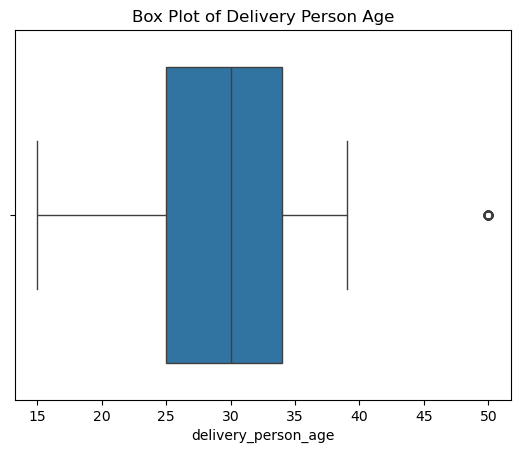

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x=df['delivery_person_age'])
plt.title('Box Plot of Delivery Person Age')
plt.show()

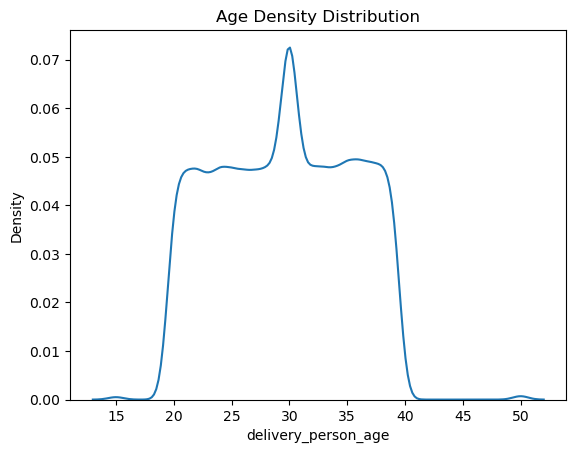

In [35]:
sns.kdeplot(df['delivery_person_age'])
plt.title('Age Density Distribution')
plt.show()

### Note
Although 53 observations were identified as statistical outliers using the IQR method, these ages fall within a realistic range for delivery personnel. Therefore, the observations were retained to preserve genuine business information.

#### Delivery person Ratings Outliers Analysis

In [36]:
Q1 = df['delivery_person_ratings'].quantile(0.25)
Q3 = df['delivery_person_ratings'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
higher_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Fence: {lower_fence:.2f}")
print(f"Upper Fence: {higher_fence:.2f}")

Q1: 4.6
Q3: 4.8
IQR: 0.20
Lower Fence: 4.30
Upper Fence: 5.10


In [37]:
outliers = df[
    (df['delivery_person_ratings'] < lower_fence) |
    (df['delivery_person_ratings'] > higher_fence)
]

print('Total Outliers:', len(outliers))

Total Outliers: 5345


In [38]:
outliers_pct = len(outliers) / len(df) * 100

print(f'outlier_pct : {outliers_pct:.2f}%')

outlier_pct : 11.73%


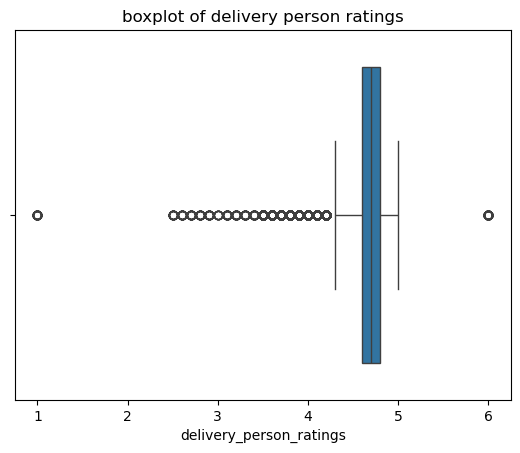

In [39]:
sns.boxplot(x=df['delivery_person_ratings'])
plt.title('boxplot of delivery person ratings')
plt.show()

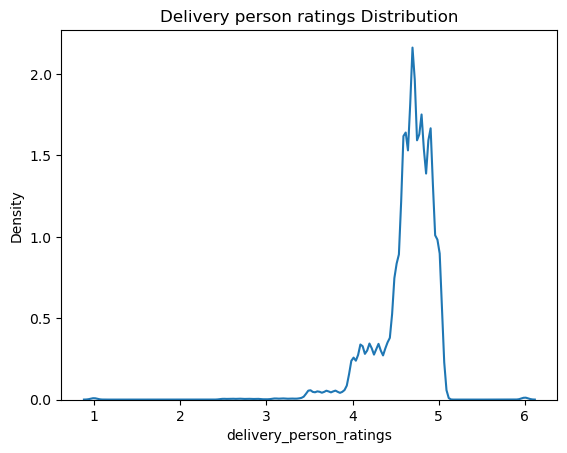

In [40]:
sns.kdeplot(df['delivery_person_ratings'])
plt.title('Delivery person ratings Distribution')
plt.show()

In [41]:
# Remove a outliers
# kyunki rating logically 5 se zyada nahi honi chahiye. Ye statistical outlier nahi, balki data quality issue ko remove karna hai.
df = df[df['delivery_person_ratings'] <= 5].copy()

#### NOTE
The delivery person rating should be between 1 and 5. During the outlier analysis, 5345 records were found with a rating of 6, which is not a valid rating value. These records were removed because they appear to be data entry errors. All other ratings between 1 and 5 were kept, even if they were identified as statistical outliers, because they represent real customer feedback and are important for business analysis.

#### Time Taken(min)


In [42]:
Q1 = df['time_taken (min)'].quantile(0.25)
Q3 = df['time_taken (min)'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
higher_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Fence: {lower_fence:.2f}")
print(f"Upper Fence: {higher_fence:.2f}")

Q1: 19.0
Q3: 32.0
IQR: 13.00
Lower Fence: -0.50
Upper Fence: 51.50


In [43]:
outliers_timetaken = df[
    (df['time_taken (min)'] < lower_fence) |
    (df['time_taken (min)'] > higher_fence)
]
print(f'total_outliers: {len(outliers_timetaken)}')

total_outliers: 270


In [44]:
outliers_pct = len(outliers_timetaken) / len(df) * 100

print(f'outliers_pct: {outliers_pct:.2f}%')

outliers_pct: 0.59%


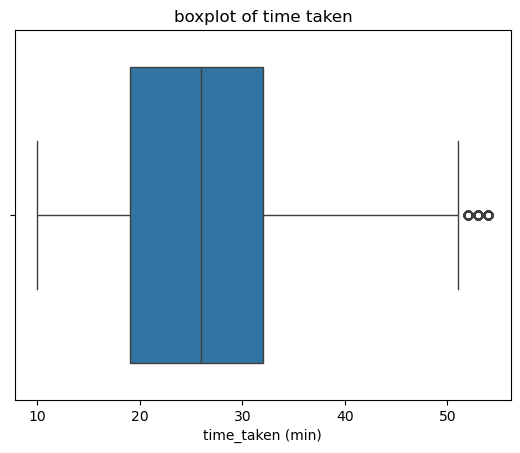

In [45]:
sns.boxplot(x=df['time_taken (min)'])
plt.title('boxplot of time taken')
plt.show()

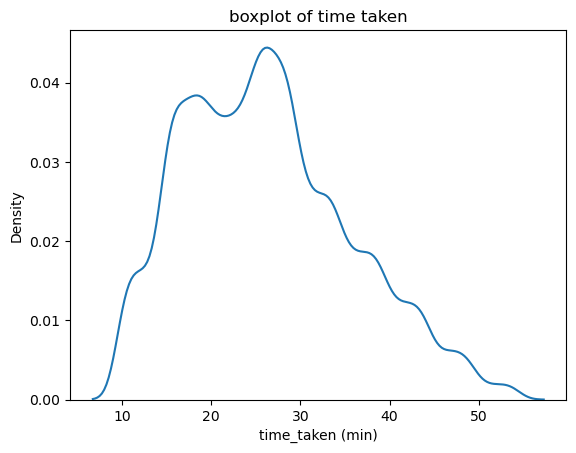

In [46]:
sns.kdeplot(df['time_taken (min)'])
plt.title('boxplot of time taken')
plt.show()

### NOTE
The IQR method identified 270 observations (0.59%) as statistical outliers. However, the maximum delivery time observed was only 54 minutes, which is a realistic value in a food delivery business. Therefore, these observations were retained as they represent valid business scenarios rather than data quality issues.

In [69]:
Q1 = df['prep_time_minutes'].quantile(0.25)
Q3 = df['prep_time_minutes'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
higher_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Fence: {lower_fence:.2f}")
print(f"Upper Fence: {higher_fence:.2f}")

Q1: 5.0
Q3: 15.0
IQR: 10.00
Lower Fence: -10.00
Upper Fence: 30.00


In [70]:
outliers_count = df[
    (df['prep_time_minutes'] < lower_fence) |
    (df['prep_time_minutes'] > higher_fence)
]
print(len(outliers_count))

0


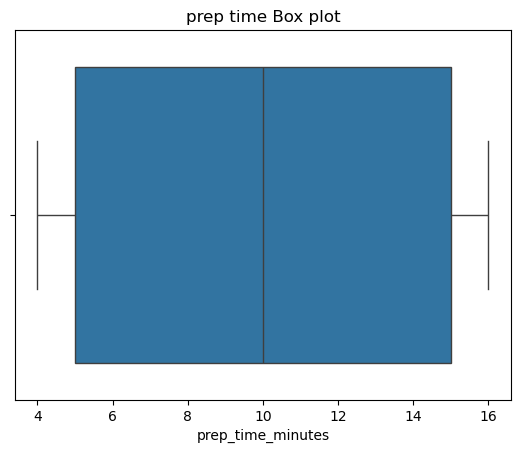

In [71]:
sns.boxplot(x=df['prep_time_minutes'])
plt.title('prep time Box plot')
plt.show()

# Feature Engineering

Created new features such as Order Hour, Time Slot, Weekend Indicator, Distance between restaurant and delivery location, and Preparation Time to derive deeper operational insights.

In [65]:
df['order_timestamp'] = pd.to_datetime(
    df['order_date'].dt.strftime('%Y-%m-%d')
    + ' '
    + df['time_orderd'].astype(str),
    errors='coerce'
)

df['picked_timestamp'] = pd.to_datetime(
    df['order_date'].dt.strftime('%Y-%m-%d')
    + ' '
    + df['time_order_picked'].astype(str),
    errors='coerce'
)

## Timestamp Creation

#### Separate date and time fields were combined to create complete timestamps for order placement and pickup events. This enabled accurate calculation of operational time-based metrics.

In [66]:
mask = df['picked_timestamp'] < df['order_timestamp']

df.loc[mask, 'picked_timestamp'] = (
    df.loc[mask, 'picked_timestamp']
    + pd.Timedelta(days=1)
)

### Midnight Correction

Some pickup times occurred after midnight (e.g., order placed at 23:55 and picked at 00:05). To ensure correct duration calculations, pickup timestamps occurring earlier than order timestamps were adjusted by adding one day.


### Business Impact

This correction prevents negative preparation times and ensures that operational metrics accurately reflect real-world delivery workflows.

In [67]:
mask = df['picked_timestamp'] < df['order_timestamp']
mask.sum()

0

### 1) Prep_time_minutes

In [68]:
df['prep_time_minutes'] = (
    df['picked_timestamp'] - df['order_timestamp']
).dt.total_seconds()/60

###  Prep_Time_Minutes

A new feature, Prep_Time_Minutes, was created by calculating the time difference between order placement and order pickup timestamps.

### Why this feature?

Preparation time directly reflects restaurant processing efficiency and is a key factor influencing overall delivery performance.

### Business Value

Higher preparation times may indicate kitchen delays, operational bottlenecks, or increased order complexity. This feature helps identify factors affecting delivery speed and customer satisfaction.

### Order hour

In [72]:
df['order_hour']  = df['order_timestamp'].dt.hour

### Delivery Distance

In [73]:
from geopy.distance import geodesic

df['distance_km'] = df.apply(
    lambda row:geodesic(
        (row['restaurant_latitude'], row['restaurant_longitude']),
        (row['delivery_location_latitude'], row['delivery_location_longitude'])
    ).km,
    axis=1
)

###  3. Delivery Speed (km/min ya km/hr)

Delivery Speed = Distance / Delivery Time

Insights:

Best-performing riders
Best-performing cities
Vehicle efficiency

In [74]:
df['delivery_speed'] = (
    df['distance_km'] / (df['time_taken (min)']/60)
)

### 4. Time Slot

Morning / Afternoon / Evening / Night

Kyun?
Business scheduling decisions isi se aati hain.

Insights:

Peak order period
Worst performing shift
Rider allocation optimization

In [75]:
def get_slot(hour):
    if hour < 12:
        return 'morning'
    elif hour < 17:
        return 'Afternoon'
    elif hour < 21:
        return 'Evening'
    else:
        return 'Night'

df['time_slot'] = df['order_hour'].apply(get_slot)

### 5. Delayed Order Flag

Delayed = Delivery Time > 45 min

Kyun?
Isse tum root cause analysis kar sakte ho.

Question:

Delayed orders ke peeche sabse bada reason kya hai?

Traffic?
Weather?
Distance?
Multiple deliveries?

Ye manager-level insight hai.

In [76]:
df['is_delayed'] = (
    df['time_taken (min)'] > 45
).astype(int)

# Day of week

In [77]:
df = df.assign(
    day_week=df['order_timestamp'].dt.day_name()
)

### 8)  IS_weekend

In [78]:
df['is_weekend'] = (
    df['order_timestamp'].dt.dayofweek >= 5).astype(int)

### 9. Operational Risk Score

In [79]:
df['high_risk_delivery'] = (
    (df['road_traffic_density'] == 'jam') &
    (df['weather_conditions'].isin(['Fog', 'Stromy']))
).astype(int)

In [80]:
df.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,...,order_timestamp,picked_timestamp,prep_time_minutes,order_hour,distance_km,delivery_speed,time_slot,day_week,is_weekend,high_risk_delivery
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,...,2022-02-12 21:55:00,2022-02-12 22:10:00,15.0,21.0,10.271464,13.397562,Night,Saturday,1,0
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,...,2022-02-13 14:55:00,2022-02-13 15:05:00,10.0,14.0,6.229376,16.250546,Afternoon,Sunday,1,0
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,...,2022-03-04 17:30:00,2022-03-04 17:40:00,10.0,17.0,13.764306,39.326588,Evening,Friday,0,0
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,...,2022-02-13 09:20:00,2022-02-13 09:30:00,10.0,9.0,2.927795,8.783384,morning,Sunday,1,0
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,...,2022-02-14 19:50:00,2022-02-14 20:05:00,15.0,19.0,19.373484,28.351440,Evening,Monday,0,0


In [81]:
df_clean = df.dropna(subset = ['prep_time_minutes']).copy()


#### Note
Rather than removing records from the entire dataset, a separate analysis subset was created for preparation-time-related investigations. This approach preserves maximum information while ensuring reliable time-based calculations.

# 3. Exploratory Data Analysis (EDA)




### Average delivery time kitna hai?


In [82]:
Avg_del = df_clean['time_taken (min)'].mean()

print(f'Avg Delivery Time: {Avg_del:.2f}')

Avg Delivery Time: 26.41


## Kis city me delivery sabse slow hai?

In [83]:
city_del = df_clean.groupby('city')['time_taken (min)'].agg(
    Avg_time = 'mean'
).sort_values('Avg_time', ascending=False)

print(city_del)

                Avg_time
city                    
Semi-Urban     49.737179
Metropolitian  27.251584
Urban          23.088762


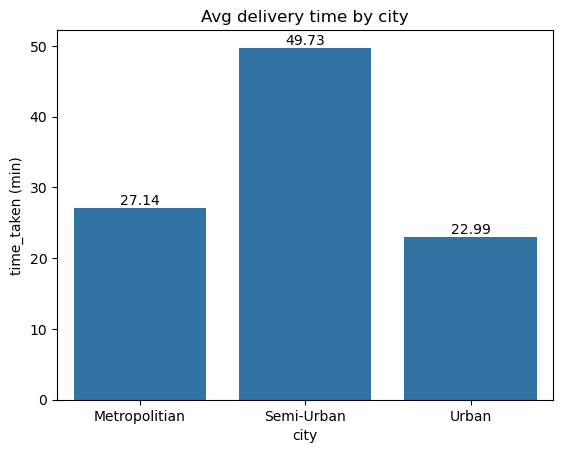

In [178]:
city_del = df_clean.groupby('city')['time_taken (min)'].mean().reset_index()

ax = sns.barplot(
    data=city_del,
    x='city',
    y='time_taken (min)'
)

# data label
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')


plt.title('Avg delivery time by city')
plt.show()

## Note
"Semi-Urban locations have significantly higher delivery times compared to Urban and Metropolitan areas, possibly due to longer travel distances, lower road connectivity, or fewer delivery partners available in those regions."

## Traffic ka impact kitna hai?

In [89]:

traffic_impact = df.groupby('road_traffic_density')['time_taken (min)'].mean().round(2).sort_values(ascending=True)
print(traffic_impact)

road_traffic_density
Low       21.46
Medium    26.70
High      27.24
Jam       31.18
Name: time_taken (min), dtype: float64


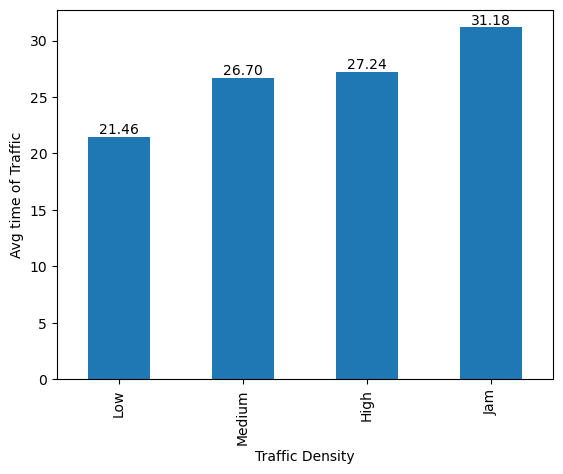

In [180]:
ax = traffic_impact.plot(kind='bar')


# data label
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')


plt.ylabel('Avg time of Traffic')
plt.xlabel('Traffic Density')
plt.show()

<Axes: xlabel='road_traffic_density', ylabel='time_taken (min)'>

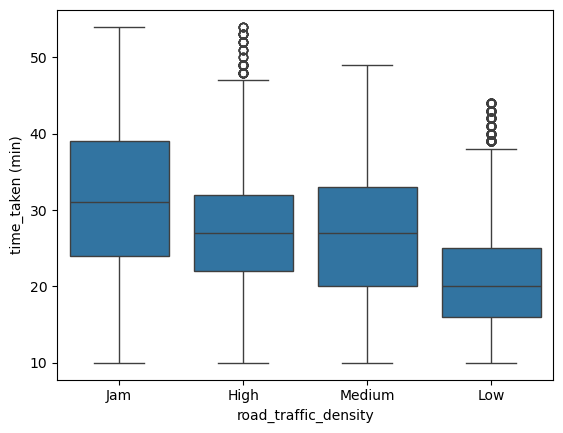

In [91]:
sns.boxplot(
    data=df_clean,
    x='road_traffic_density',
    y='time_taken (min)'
)

# Interpretation

Traffic badhne ke saath delivery time bhi badh raha hai

Road traffic density has a strong impact on delivery time. Orders delivered during traffic jams take approximately 10 minutes longer than those delivered under low traffic conditions.

# Distance aur delivery time ka relation kya hai?

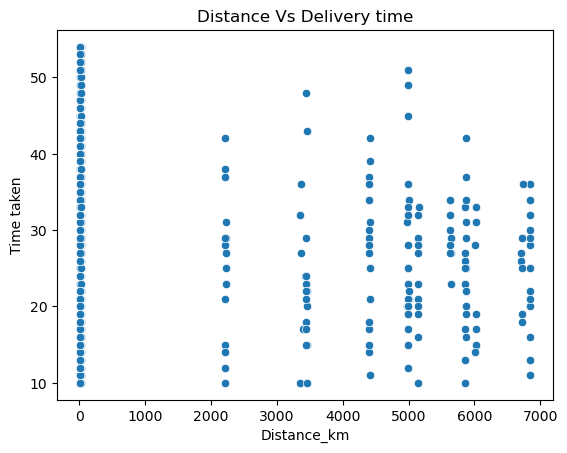

In [92]:
sns.scatterplot(
    data=df_clean,
    x='distance_km',
    y='time_taken (min)'
)

plt.xlabel('Distance_km')
plt.ylabel('Time taken')
plt.title('Distance Vs Delivery time')
plt.show()

In [93]:
df_clean['distance_km'].corr(df_clean['time_taken (min)'])

-0.001641743023626314

In [94]:
df_clean['distance_km'].describe()

count    42592.000000
mean        27.115580
std        302.095941
min          1.463837
25%          4.648811
50%          9.177366
75%         13.660293
max       6852.617172
Name: distance_km, dtype: float64

In [95]:
(df_clean['restaurant_latitude'] < 0).sum()


153

In [96]:
(df_clean['delivery_location_latitude'] < 0).sum()

0

In [97]:
df_clean[df_clean['restaurant_latitude'] < 0].head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,...,order_timestamp,picked_timestamp,prep_time_minutes,order_hour,distance_km,delivery_speed,time_slot,day_week,is_weekend,high_risk_delivery
83,0xc042,AGRRES010DEL01,34.0,4.7,-27.163303,78.057044,27.233303,78.127044,2022-02-16,22:59,...,2022-02-16 22:59:00,2022-02-16 23:05:00,6.0,22.0,6019.211231,24076.844923,Night,Wednesday,0,0
274,0xc044,AGRRES12DEL03,32.0,4.7,-27.165108,78.015053,27.225108,78.075053,2022-02-13,20:55,...,2022-02-13 20:55:00,2022-02-13 21:10:00,15.0,20.0,6018.501935,11648.713423,Evening,Sunday,1,0
1082,0xc086,GOARES010DEL03,20.0,4.7,-15.546594,73.760431,15.606594,73.820431,2022-02-13,19:59,...,2022-02-13 19:59:00,2022-02-13 20:10:00,11.0,19.0,3445.587513,7128.801752,Evening,Sunday,1,0
1774,0xc067,BHPRES13DEL02,39.0,4.5,-23.230791,77.437020,23.250791,77.457020,2022-02-13,09:15,...,2022-02-13 09:15:00,2022-02-13 09:20:00,5.0,9.0,5142.408748,10639.466375,morning,Sunday,1,0
1967,0xc061,KOLRES16DEL01,25.0,4.0,-22.539129,88.365507,22.549129,88.375507,2022-02-15,09:25,...,2022-02-15 09:25:00,2022-02-15 09:30:00,5.0,9.0,4988.108200,15751.920633,morning,Tuesday,0,0


### Now we are remove Negative on restaurant latitude

In [98]:
df_clean.loc[
    df_clean['restaurant_latitude'] < 0,
    'restaurant_latitude'
] = df_clean.loc[
    df_clean['restaurant_latitude'] < 0,
    'restaurant_latitude'
].abs()

In [99]:
df_clean['restaurant_latitude'] = df_clean['restaurant_latitude'].abs()

In [100]:
(df_clean['restaurant_latitude'] < 0).sum()


0

In [101]:
df_clean = df.drop(columns =['distance_km'], errors='ignore')

In [102]:
from geopy.distance import geodesic

df_clean['distance_km'] = df_clean.apply(
    lambda row: geodesic(
        (row['restaurant_latitude'], row['restaurant_longitude']),
        (row['delivery_location_latitude'], row['delivery_location_longitude'])
    ).km,
    axis=1
)

In [103]:
df_clean['distance_km'].describe()

count    45531.000000
mean        91.401250
std       1036.695532
min          1.463837
25%          4.654185
50%          9.246315
75%         13.740853
max      19704.910857
Name: distance_km, dtype: float64

#  negative latitudes ko positive banao aur fir uska Outliers remove kr rahe

In [104]:
Q1 = df_clean['distance_km'].quantile(0.25)
Q3 = df_clean['distance_km'].quantile(0.75)

IQR = Q3 - Q1

lower_fence = Q1 - 1.5 * IQR
higher_fence = Q3 + 1.5 * IQR

print(f"Q1: {Q1}")
print(f"Q3: {Q3}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Fence: {lower_fence:.2f}")
print(f"Upper Fence: {higher_fence:.2f}")

Q1: 4.654184877609341
Q3: 13.740852946326266
IQR: 9.09
Lower Fence: -8.98
Upper Fence: 27.37


In [105]:
outliers_timetaken = df[
    (df_clean['distance_km'] < lower_fence) |
    (df['distance_km'] > higher_fence)
]
print(f'total_outliers: {len(outliers_timetaken)}')

total_outliers: 409


In [106]:
df_clean_no_outliers = df_clean[
    (df_clean['distance_km'] >= lower_fence) &
    (df_clean['distance_km'] <= higher_fence)
].copy()

print("Before removing outliers:", df_clean.shape)
print("After removing outliers:", df_clean_no_outliers.shape)

Before removing outliers: (45531, 31)
After removing outliers: (45122, 31)


In [107]:
df_clean = df_clean[
    (df_clean['distance_km'] >= lower_fence) &
    (df_clean['distance_km'] <= higher_fence)
]

In [108]:
df_clean['distance_km'].describe()

count    45122.000000
mean         9.718633
std          5.598372
min          1.463837
25%          4.654105
50%          9.203901
75%         13.660190
max         20.942906
Name: distance_km, dtype: float64

## Distance Feature Validation and Delivery Time Analysis

During feature engineering, I calculated the delivery distance between the restaurant location and the customer delivery location using latitude and longitude values. Initially, some records showed extremely unrealistic distances of more than 6000 km, which is not valid for a food delivery business.

After investigating the extreme values, I found that some `restaurant_latitude` values had incorrect negative signs. Because of this data quality issue, the calculated distance became incorrect. I corrected those latitude values and recalculated the delivery distance using geodesic distance.

After correction, the maximum delivery distance reduced from around 6852 km to 20.94 km, which is much more realistic for a local food delivery dataset.

To validate the corrected distance feature, I created a scatter plot between `distance_km` and `time_taken (min)`. The scatter plot shows that delivery time generally increases as distance increases, but the relationship is not very strong. The correlation between distance and delivery time is approximately 0.33, which indicates a weak-to-moderate positive relationship.

This means distance is an important factor in delivery time, but it is not the only reason for delay. Other operational factors such as traffic condition, weather, city type, festival period, multiple deliveries, rider performance, and vehicle condition can also affect the final delivery time.

### Business Insight

From a business point of view, this analysis shows that longer-distance orders usually take more time, but delay cannot be explained by distance alone. The company should also monitor traffic, weather, rider workload, multiple deliveries, and city-level performance to improve delivery speed and reduce late deliveries.

### Final Conclusion

The distance feature was cleaned, validated, and made analysis-ready. After correction, the distance values became realistic, and the analysis showed that distance has a positive but limited impact on delivery time.

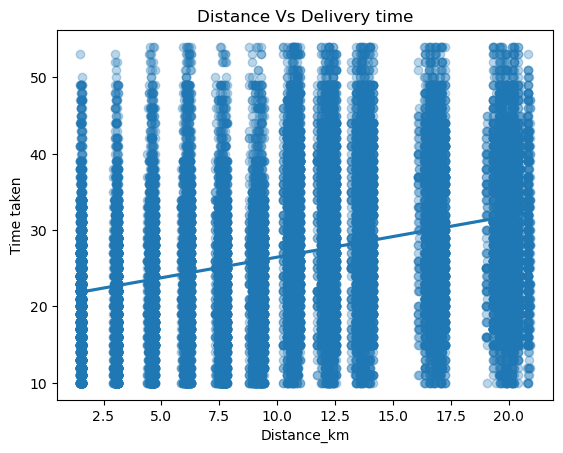

In [109]:
sns.regplot(
    data=df_clean,
    x='distance_km',
    y='time_taken (min)',
    scatter_kws={'alpha':0.3}
)
plt.xlabel('Distance_km')
plt.ylabel('Time taken')
plt.title('Distance Vs Delivery time')
plt.show()

The scatter plot shows a weak-to-moderate positive relationship between delivery distance and delivery time. The correlation value is 0.33, meaning that delivery time tends to increase with distance, but distance alone does not fully explain delivery delays. Other factors like traffic, weather, multiple deliveries, city type, and rider performance also play an important role.

### Observation

After fixing incorrect latitude values, the distance feature became realistic with a maximum distance of 20.94 km. The scatter plot shows that delivery time increases slightly with distance, but points are widely spread. This indicates that distance affects delivery time, but other operational factors also have a strong impact.

# Note 
"While validating the distance feature, I discovered 153 anomalous records where restaurant latitude values had incorrect negative signs, resulting in unrealistic delivery distances of 5,000–7,000 km. Since these represented only 0.36% of the dataset and were clear data-quality issues, they were removed before further analysis."

In [110]:
### Prep time aur total delivery time correlated hain kya?

df_clean['prep_time_minutes'].corr(df_clean['time_taken (min)'])

-0.0034545575590673064

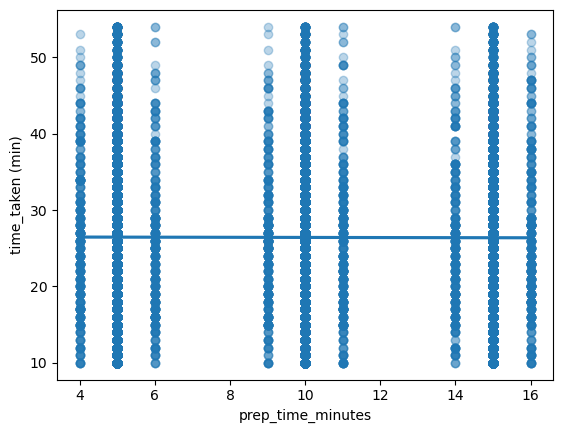

In [111]:
sns.regplot(
    data=df_clean,
    x='prep_time_minutes',
    y='time_taken (min)',
    scatter_kws={'alpha':0.3}
)
plt.show()

### Prep Time vs Delivery Time

- Calculated the Pearson correlation between preparation time and total delivery time.
- The correlation coefficient was -0.0034, which is very close to zero.
- This indicates that preparation time has little to no linear relationship with total delivery time.
- Delivery duration appears to be influenced more by factors such as traffic conditions, distance, and location rather than preparation time.

In [112]:
# weather_conditions vs time_taken(min)

weather_time = df.groupby('weather_conditions')['time_taken (min)'].mean().sort_values(ascending=True).round(2)
print(weather_time)

weather_conditions
Sunny         21.86
Stormy        25.87
Sandstorms    25.88
Windy         26.12
Fog           28.77
Cloudy        28.92
Name: time_taken (min), dtype: float64


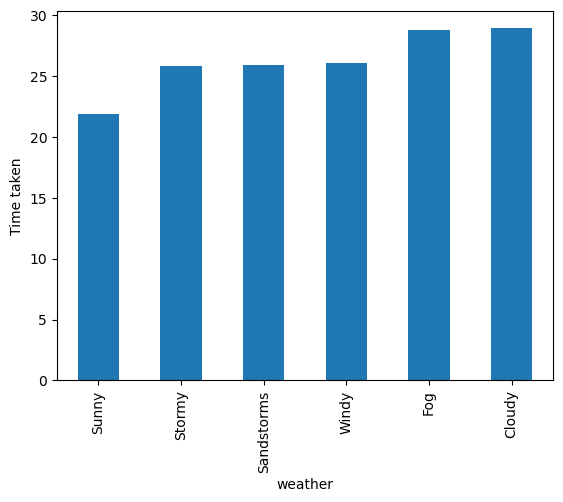

In [113]:
weather_time.plot(kind='bar')
plt.xlabel('weather')
plt.ylabel('Time taken')
plt.show()

In [194]:
## festival vs time_taken(min)
festival_time = (
    df.groupby('festival').agg(
    avg_time = ('time_taken (min)', 'mean')
)
    .reset_index()
)
festival_time = festival_time.round(2).sort_values(by='avg_time', ascending=False)

print(festival_time)



  festival  avg_time
1      Yes     45.52
0       No     25.91


In [195]:
festival_time['festival_label'] = festival_time['festival'].map({
    'No': 'No Festival Day',
    'Yes': 'Festival day'
})

festival_time

,festival,avg_time,festival_label
1,Yes,45.52,Festival day
0,No,25.91,No Festival Day


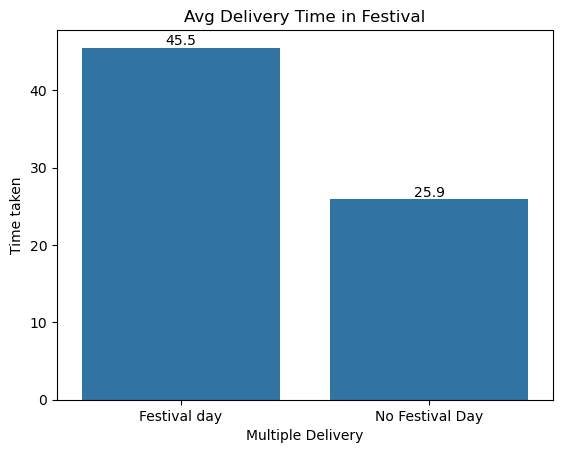

In [197]:
ax = sns.barplot(
    data=festival_time,
    x='festival_label',
    y='avg_time'
)

# Data labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f')
    

plt.title('Avg Delivery Time in Festival')
plt.xlabel('Multiple Delivery')
plt.ylabel('Time taken')
plt.show()

# Business problem:

### What factors are driving delivery delays, and what actions can improve delivery efficiency and customer satisfaction?

# 1. Delivery Performance Overview


## Business Question 1

How efficient is the current delivery operation?


In [122]:
total_orders = df_clean['id'].nunique()
average_del_time = df_clean['time_taken (min)'].mean()
median_del_time = df_clean['time_taken (min)'].median()
min_del_time = df_clean['time_taken (min)'].min()
max_del_time = df_clean['time_taken (min)'].max()

delayed_orders = (df['is_delayed'] == 1).sum()
delayed_order_percent = delayed_orders / len(df) * 100

print(f"Total Orders: {total_orders}")
print(f"Average Delivery Time: {average_del_time:.2f} minutes")
print(f"Median Delivery Time: {median_del_time:.2f} minutes")
print(f"Minimum Delivery Time: {min_del_time:.2f} minutes")
print(f"Maximum Delivery Time: {max_del_time:.2f} minutes")
print(f"Delayed Orders: {delayed_orders}")
print(f"Delayed Order Percentage: {delayed_order_percent:.2f}%")

Total Orders: 45122
Average Delivery Time: 26.30 minutes
Median Delivery Time: 26.00 minutes
Minimum Delivery Time: 10.00 minutes
Maximum Delivery Time: 54.00 minutes
Delayed Orders: 1561
Delayed Order Percentage: 3.43%


In [123]:
pd.set_option('display.max_columns', None)
df.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken (min),is_delayed,order_timestamp,picked_timestamp,prep_time_minutes,order_hour,distance_km,delivery_speed,time_slot,day_week,is_weekend,high_risk_delivery
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,1,2022-02-12 21:55:00,2022-02-12 22:10:00,15.0,21.0,10.271464,13.397562,Night,Saturday,1,0
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,0,2022-02-13 14:55:00,2022-02-13 15:05:00,10.0,14.0,6.229376,16.250546,Afternoon,Sunday,1,0
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,0,2022-03-04 17:30:00,2022-03-04 17:40:00,10.0,17.0,13.764306,39.326588,Evening,Friday,0,0
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,0,2022-02-13 09:20:00,2022-02-13 09:30:00,10.0,9.0,2.927795,8.783384,morning,Sunday,1,0
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,0,2022-02-14 19:50:00,2022-02-14 20:05:00,15.0,19.0,19.373484,28.351440,Evening,Monday,0,0


# Business Question 2

What are the biggest drivers of delivery delays?

Analyze:

road_traffic_density
weather_conditions
multiple_deliveries
distance_km
prep_time_minutes

<!-- Visuals:

Barplots
Boxplots

Final Insight:

Traffic congestion and long-distance orders are the primary causes of delays. -->

In [124]:
def delay_summary(df_clean, column):
    summary = (
        df_clean.groupby(column, dropna=False, observed=False)
        .agg(
            total_orders=('id', 'nunique'),
            delayed_orders=('is_delayed', 'sum'),
            avg_delivery_time=('time_taken (min)', 'mean')
        )
        
    )

    summary['delay_rate'] = (
        summary['delayed_orders'] / summary['total_orders'] * 100
    )

    return summary.sort_values(by='delay_rate', ascending=False).round(2)




# Categorical features
road_traffic_delay = delay_summary(df_clean, 'road_traffic_density')
weather_condition_delay = delay_summary(df_clean, 'weather_conditions')
multiple_delivery_delay = delay_summary(df_clean, 'multiple_deliveries')


# Distance bucket
df_clean['distance_bucket'] = pd.cut(
    df_clean['distance_km'],
    bins=[0, 2, 5, 8, 12, 16, 25],
    labels=['0-2 km', '2-5 km', '5-8 km', '8-12 km', '12-16 km', '16+ km'],
    include_lowest=True
)

distance_delay = delay_summary(df_clean, 'distance_bucket')


# Prep time bucket
df_clean['prep_time_bucket'] = pd.cut(
    df_clean['prep_time_minutes'],
    bins=[0, 5, 10, 15, 20, 30, 60],
    labels=['0-5 min', '5-10 min', '10-15 min', '15-20 min', '20-30 min', '30+ min'],
    include_lowest=True
)

prep_time_delay = delay_summary(df_clean, 'prep_time_bucket')


print("Road Traffic Delay Analysis:")
print(road_traffic_delay)

print("\nWeather Condition Delay Analysis:")
print(weather_condition_delay)

print("\nMultiple Delivery Delay Analysis:")
print(multiple_delivery_delay)

print("\nDistance Delay Analysis:")
print(distance_delay)

print("\nPrep Time Delay Analysis:")
print(prep_time_delay)

Road Traffic Delay Analysis:
                      total_orders  delayed_orders  avg_delivery_time  \
road_traffic_density                                                    
Jam                          14046            1191              31.18   
High                          4398             149              27.23   
Medium                       10884             187              26.71   
Low                          15794              16              21.42   

                      delay_rate  
road_traffic_density              
Jam                         8.48  
High                        3.39  
Medium                      1.72  
Low                         0.10  

Weather Condition Delay Analysis:
                    total_orders  delayed_orders  avg_delivery_time  \
weather_conditions                                                    
Cloudy                      7482             412              28.92   
Fog                         8039             406              28.82   
San

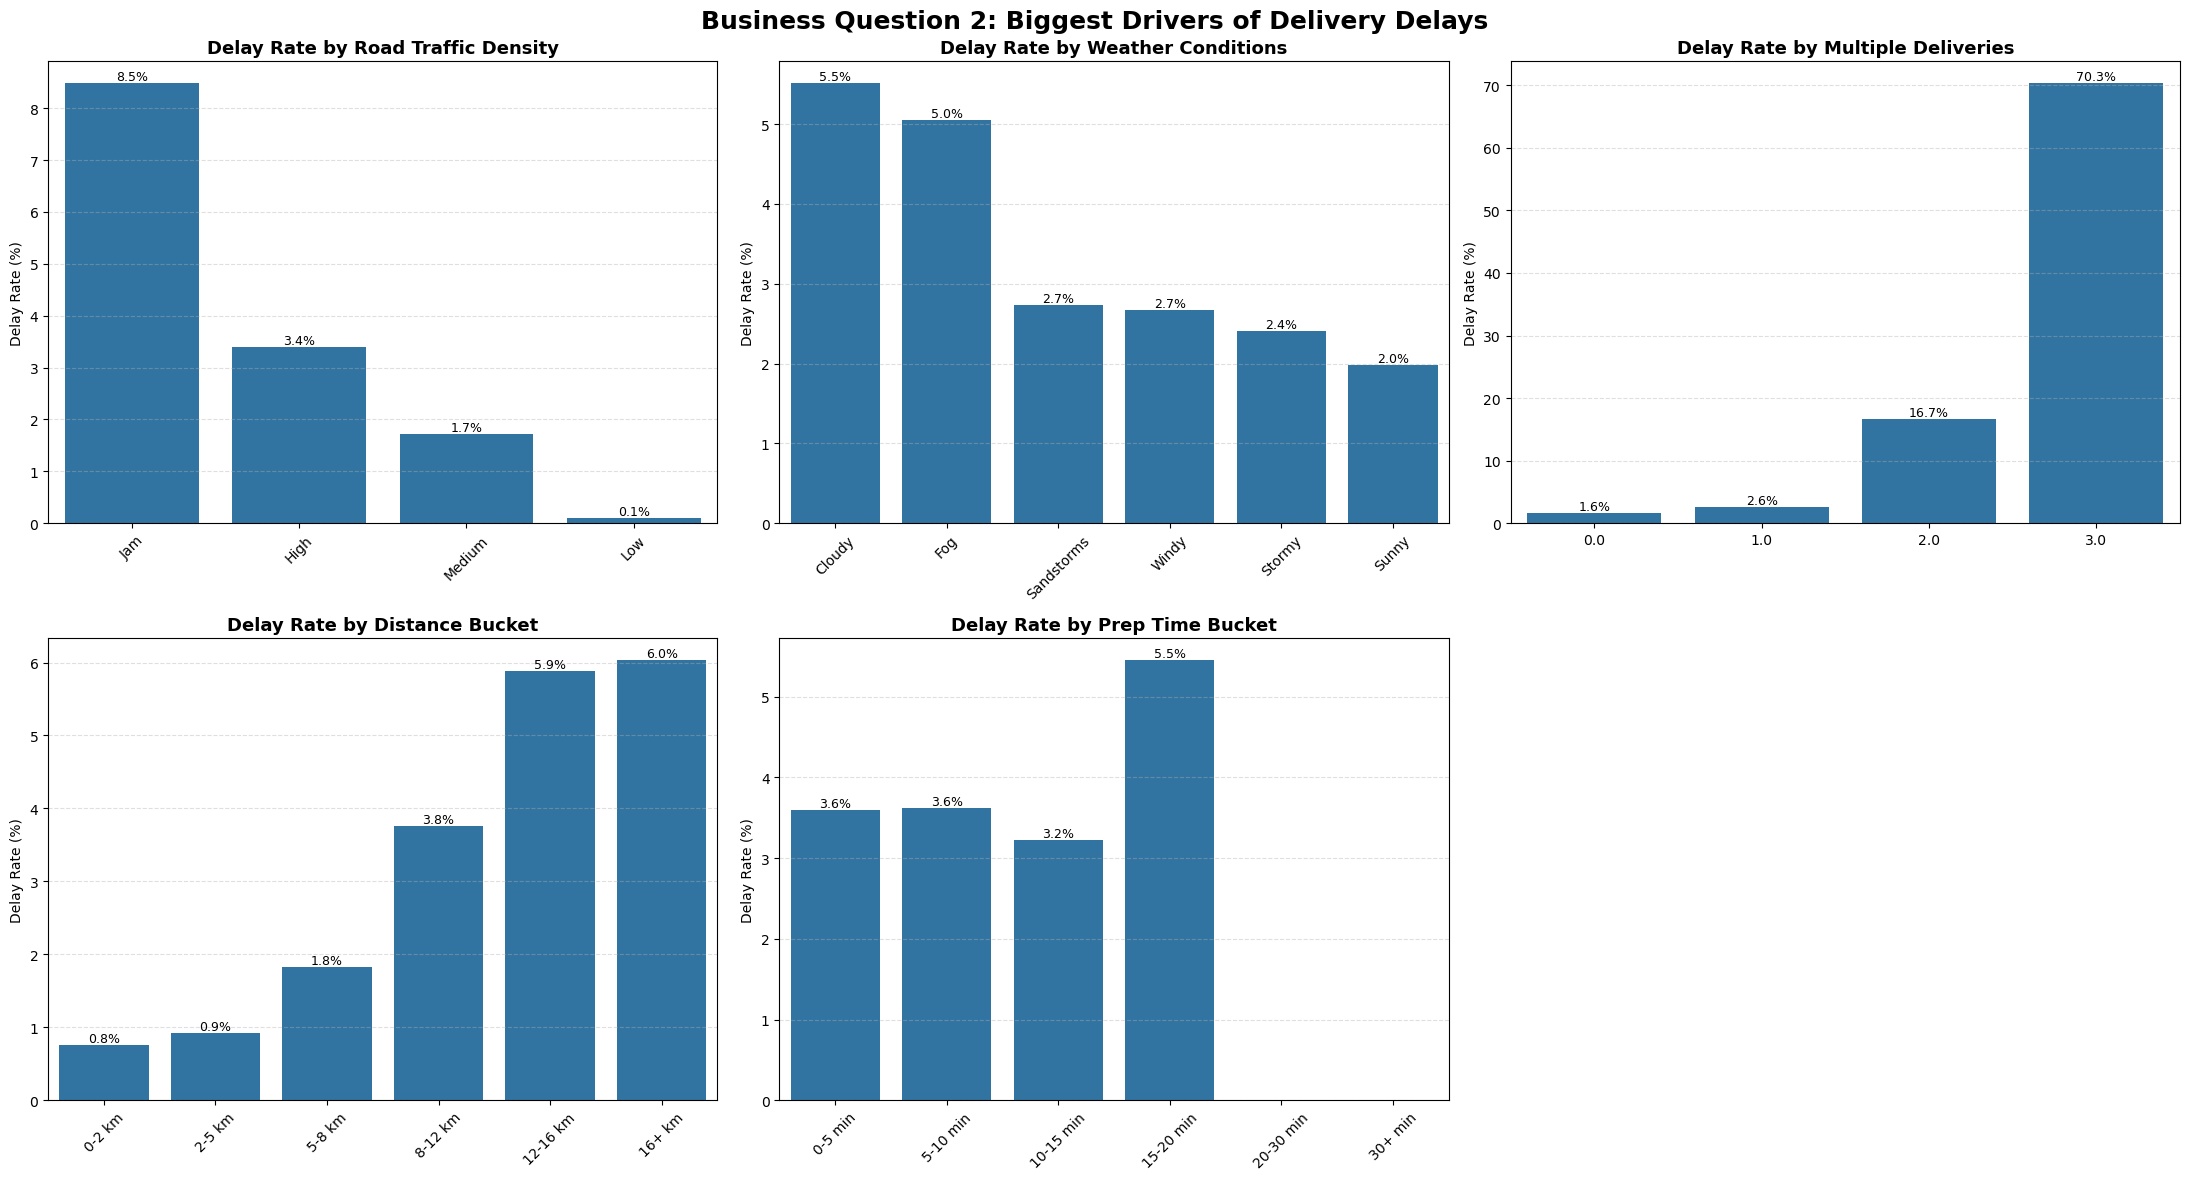

In [125]:
import matplotlib.pyplot as plt
import seaborn as sns

# Graph ke liye index ko column mein convert karna zaroori hai
road_traffic_plot = road_traffic_delay.reset_index()
weather_plot = weather_condition_delay.reset_index()
multiple_delivery_plot = multiple_delivery_delay.reset_index()
distance_plot = distance_delay.reset_index()
prep_time_plot = prep_time_delay.reset_index()


# Subplots create
fig, axes = plt.subplots(2, 3, figsize=(22, 12))
axes = axes.flatten()


# Reusable function for barplot
def plot_delay_rate(ax, data, x_col, title, rotation=45):
    sns.barplot(
        data=data,
        x=x_col,
        y='delay_rate',
        ax=ax
    )
    
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('Delay Rate (%)')
    ax.tick_params(axis='x', rotation=rotation)
    
    # Bar ke upar percentage label
    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', fontsize=9)
    
    ax.grid(axis='y', linestyle='--', alpha=0.4)


# 1. Traffic delay
plot_delay_rate(
    axes[0],
    road_traffic_plot,
    'road_traffic_density',
    'Delay Rate by Road Traffic Density'
)

# 2. Weather delay
plot_delay_rate(
    axes[1],
    weather_plot,
    'weather_conditions',
    'Delay Rate by Weather Conditions'
)

# 3. Multiple deliveries delay
plot_delay_rate(
    axes[2],
    multiple_delivery_plot,
    'multiple_deliveries',
    'Delay Rate by Multiple Deliveries',
    rotation=0
)

# 4. Distance delay
plot_delay_rate(
    axes[3],
    distance_plot,
    'distance_bucket',
    'Delay Rate by Distance Bucket'
)

# 5. Prep time delay
plot_delay_rate(
    axes[4],
    prep_time_plot,
    'prep_time_bucket',
    'Delay Rate by Prep Time Bucket'
)

# 6th empty subplot remove
fig.delaxes(axes[5])

plt.suptitle(
    'Business Question 2: Biggest Drivers of Delivery Delays',
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Key Insights

- **Multiple deliveries is the strongest delay driver.** Orders with 3 multiple deliveries have the highest delay rate of **70.3%**, and their average delivery time is **47.82 minutes**. This clearly shows that rider workload strongly impacts delivery delays.

- **Traffic congestion also increases delay risk.** Orders delivered during **Jam traffic** have the highest traffic-based delay rate of **8.49%**, while Low traffic has only **0.12%** delay rate. This indicates that road congestion is a major operational factor.

- **Weather conditions affect delivery performance.** Cloudy and Fog conditions show the highest delay rates, around **5.48%** and **5.05%**, compared to Sunny weather at **1.99%**.

- **Long-distance deliveries are more likely to be delayed.** Orders above **12 km** show higher delay rates compared to short-distance orders. This confirms that distance has a positive impact on delivery time.

- **Preparation time has a limited impact compared to multiple deliveries and traffic.** Prep time buckets show relatively close delay rates, so preparation time is not the strongest delay driver in this dataset.

### Business Conclusion

The biggest contributors to delivery delays are **multiple deliveries, traffic congestion, bad weather, and long delivery distance**. Among these, multiple deliveries has the strongest impact. To reduce delays, the business should optimize rider assignment, avoid overloading riders with multiple orders, and improve delivery planning during jam traffic and poor weather conditions.

# Business Question 3

## Are delays caused by restaurant preparation or delivery execution?

### Questions:

#### High prep time orders ka average delivery time?
#### Low prep time orders ka average delivery time?


In [126]:
df_time = df_clean.copy()

# Total customer wait time
df_time['Total_wait_time'] = (
    df_time['prep_time_minutes'] + df_time['time_taken (min)']
)

# Prep time buckets
df_time['time_bucket']  = pd.cut(
    df_time['prep_time_minutes'],
    bins=[0,5,10,15,20,60],
    labels=['0-5', '5-10', '10-15', '15-20', '20+'],
    include_lowest=True
)

# Customer delay based on total time
df_time['customer_delay'] = (
    df_time['Total_wait_time'] > 45
).astype(int)

restaurant_rider_analysis = (
    df_time.groupby('time_bucket', observed=False).agg(
        Total_orders = ('id', 'nunique'),
        avg_prep_time = ('prep_time_minutes', 'mean'),
        avg_delivery_time = ('time_taken (min)', 'mean'),
        avg_total_customer_time = ('Total_wait_time', 'mean'),
        delayed_orders = ('customer_delay', sum)
    )
    .reset_index()
)

restaurant_rider_analysis['delay_rate'] = (
    restaurant_rider_analysis['delayed_orders'] / restaurant_rider_analysis['Total_orders'] * 100
)

restaurant_rider_analysis = restaurant_rider_analysis.round(2)

print(restaurant_rider_analysis)

  time_bucket  Total_orders  avg_prep_time  avg_delivery_time  \
0         0-5         13990           4.97              26.45   
1        5-10         14054           9.87              26.49   
2       10-15         13991          14.85              26.32   
3       15-20           404          16.00              26.02   
4         20+             0            NaN                NaN   

   avg_total_customer_time  delayed_orders  delay_rate  
0                    31.42            1294        9.25  
1                    36.35            2513       17.88  
2                    41.18            4163       29.75  
3                    42.02             116       28.71  
4                      NaN               0         NaN  


C:\Users\jauwa\AppData\Local\Temp\ipykernel_23180\3478096476.py:22: FutureWarning: The provided callable <built-in function sum> is currently using SeriesGroupBy.sum. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "sum" instead.
  df_time.groupby('time_bucket', observed=False).agg(


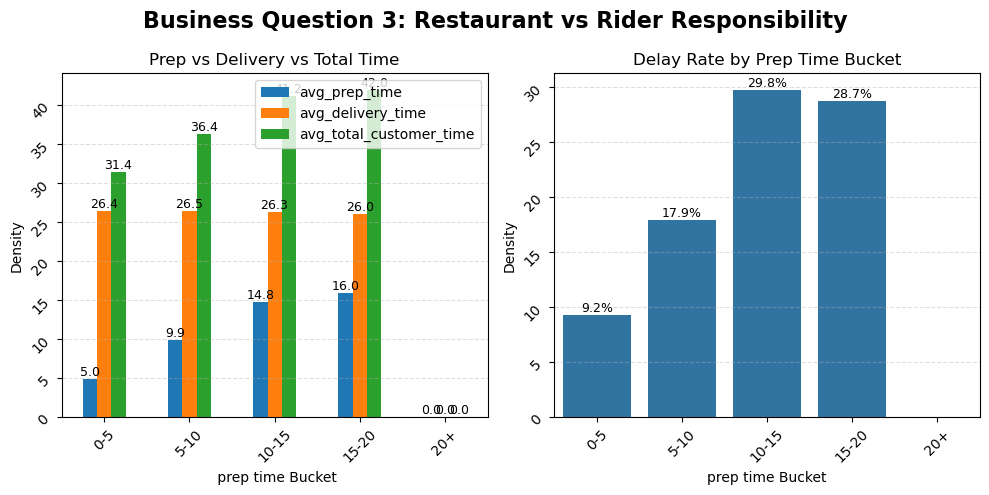

In [127]:
fig, axes = plt.subplots(1,2, figsize=(10,5))


# Visual 1: Prep vs Delivery vs Total Time

restaurant_rider_analysis.plot(
    x='time_bucket',
    y=['avg_prep_time', 'avg_delivery_time', 'avg_total_customer_time'],
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Prep vs Delivery vs Total Time')
axes[0].set_xlabel(' prep time Bucket')
axes[0].set_ylabel('Density')
axes[0].tick_params(rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=9)


# Visual 2: Delay Rate by Prep Time Bucket
sns.barplot(
    data=restaurant_rider_analysis,
    x='time_bucket',
    y='delay_rate',
    ax=axes[1]
)
axes[1].set_title('Delay Rate by Prep Time Bucket')
axes[1].set_xlabel('prep time Bucket')
axes[1].set_ylabel('Density')
axes[1].tick_params(rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9)

    plt.suptitle(
    'Business Question 3: Restaurant vs Rider Responsibility',
    fontsize=16,
    fontweight='bold'
    )
plt.tight_layout()
plt.show()



### Business Question 4

### How much does delivery distance affect delivery time?

Analyze:

#### distance_km vs time_taken(min)
##### distance categories


In [128]:
delivery_distance_analysis = (
    df_clean.groupby('distance_bucket', observed=False).agg(
        Total_orders = ('id', 'nunique'),
        median_delivery_time = ('time_taken (min)', 'median'),
        Avg_Delivery_time = ('time_taken (min)', 'mean'),
        Total_delay = ('is_delayed', 'sum')
        
    )
    .reset_index()

)

delivery_distance_analysis['delay_rate'] = (
    delivery_distance_analysis['Total_delay'] /  delivery_distance_analysis['Total_orders'] * 100
)

delivery_distance_analysis =  delivery_distance_analysis.round(2)


print(delivery_distance_analysis)

  distance_bucket  Total_orders  median_delivery_time  Avg_Delivery_time  \
0          0-2 km          4070                  20.0              21.43   
1          2-5 km          8080                  22.0              22.50   
2          5-8 km          8141                  25.0              24.64   
3         8-12 km          8637                  26.0              27.16   
4        12-16 km          7571                  29.0              29.74   
5          16+ km          8623                  29.0              29.84   

   Total_delay  delay_rate  
0           31        0.76  
1           74        0.92  
2          148        1.82  
3          325        3.76  
4          445        5.88  
5          520        6.03  


In [129]:
distance_time_corr = df_clean['distance_km'].corr(df['time_taken (min)'])

print(f"Correlation between Distance and Delivery Time: {distance_time_corr:.2f}")

Correlation between Distance and Delivery Time: 0.32


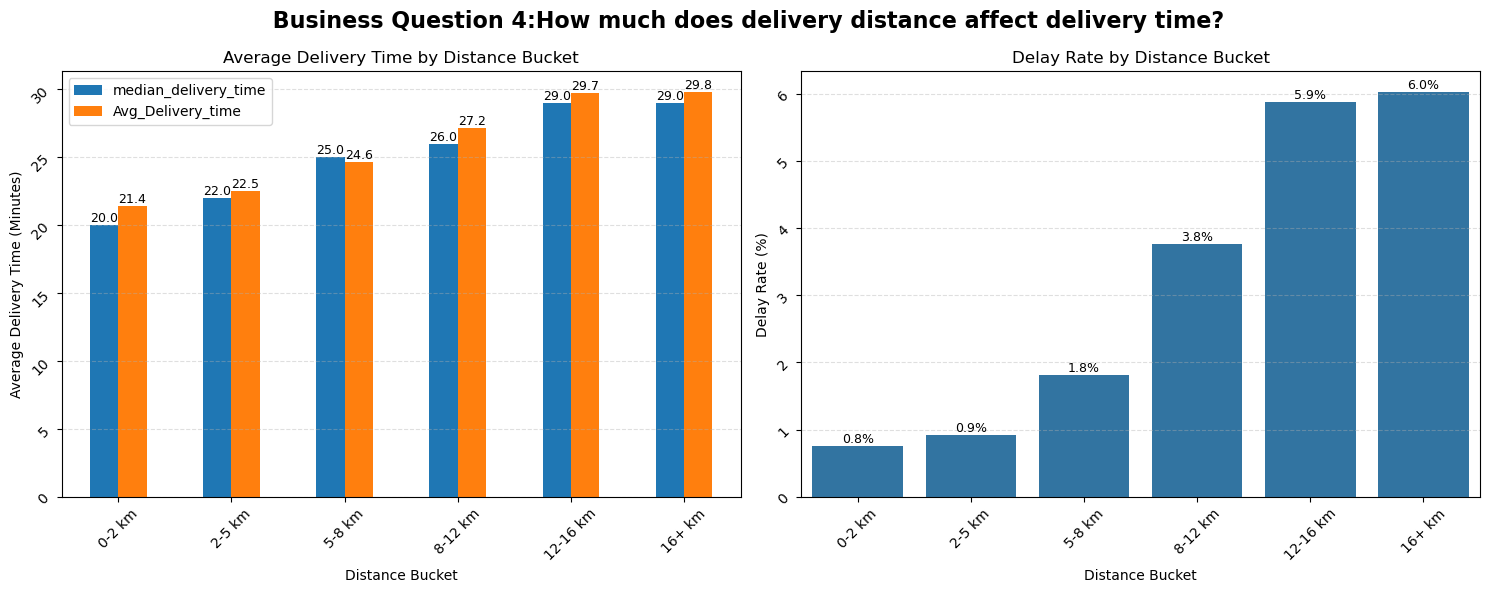

In [130]:
fig, axes = plt.subplots(1,2, figsize=(15,6))

# delivery_distance_analysis

delivery_distance_analysis.plot(
    x='distance_bucket',
    y=['median_delivery_time',  'Avg_Delivery_time'],
    kind='bar',
    ax=axes[0]
)

# sns.barplot(
#     data=delivery_distance_analysis,
#     x='distance_bucket',
#     y='Avg_Delivery_time',
#     ax=axes[0]
# )

axes[0].set_title('Average Delivery Time by Distance Bucket')
axes[0].set_xlabel('Distance Bucket')
axes[0].set_ylabel('Average Delivery Time (Minutes)')
axes[0].tick_params(rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=9)


sns.barplot(
    data=delivery_distance_analysis,
    x='distance_bucket',
    y='delay_rate',
    ax=axes[1]
)

axes[1].set_title('Delay Rate by Distance Bucket')
axes[1].set_xlabel('Distance Bucket')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9)

plt.suptitle(
    ' Business Question 4:How much does delivery distance affect delivery time?',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Key Insights: Distance Impact on Delivery Time

- Delivery distance has a clear positive impact on delivery time. As distance increases, both average and median delivery time also increase.

- Short-distance orders between **0–2 km** have an average delivery time of **21.43 minutes** and a delay rate of only **0.76%**.

- Long-distance orders above **12 km** have an average delivery time of around **29.7–29.8 minutes**, and their delay rate increases to nearly **6%**.

- The biggest jump in delay risk starts after **8 km**. Delay rate increases from **1.82%** in the **5–8 km** bucket to **3.76%** in the **8–12 km** bucket.

- Orders above **16 km** have the highest delay rate of **6.03%**, showing that long-distance deliveries are more likely to be delayed.

- Average and median delivery time are close to each other in most buckets, which means delivery time increases steadily with distance and is not only driven by a few extreme outliers.

### Business Conclusion

Delivery distance is an important factor affecting delivery performance. Longer-distance orders take more time and have a higher chance of delay. The business should pay special attention to orders beyond **8 km**, especially during peak traffic hours, because delay risk increases sharply after this distance range.

### Recommendation

During peak hours or bad traffic conditions, the company can optimize delivery radius, assign experienced riders for long-distance orders, or increase delivery time estimates for orders above **8 km** to improve customer expectations and reduce late-delivery complaints.


## Business Question 5

How severely does traffic impact delivery performance?




In [131]:
traffic_order = ['Low', 'Medium', 'High', 'Jam']

df_clean['road_traffic_analysis'] = pd.Categorical(
    df_clean['road_traffic_density'],
    categories= traffic_order,
    ordered=True
)

Traffic_deliver_analysis =(df_clean.groupby('road_traffic_analysis', observed=False).agg(
    Total_orders = ('id', 'nunique'),
    Median_del_time = ('time_taken (min)', 'median'),
    Avg_del_time = ('time_taken (min)', 'mean'),
    order_delay = ('is_delayed', 'sum')
).reset_index()
)

Traffic_deliver_analysis['delay_rate'] = (
    Traffic_deliver_analysis['order_delay'] / Traffic_deliver_analysis['Total_orders'] * 100
)

Traffic_deliver_analysis = Traffic_deliver_analysis.round(2)

Traffic_deliver_analysis

,road_traffic_analysis,Total_orders,Median_del_time,Avg_del_time,order_delay,delay_rate
0,Low,15794,21.0,21.42,16,0.10
1,Medium,10884,27.0,26.71,187,1.72
2,High,4398,27.0,27.23,149,3.39
3,Jam,14046,31.0,31.18,1191,8.48


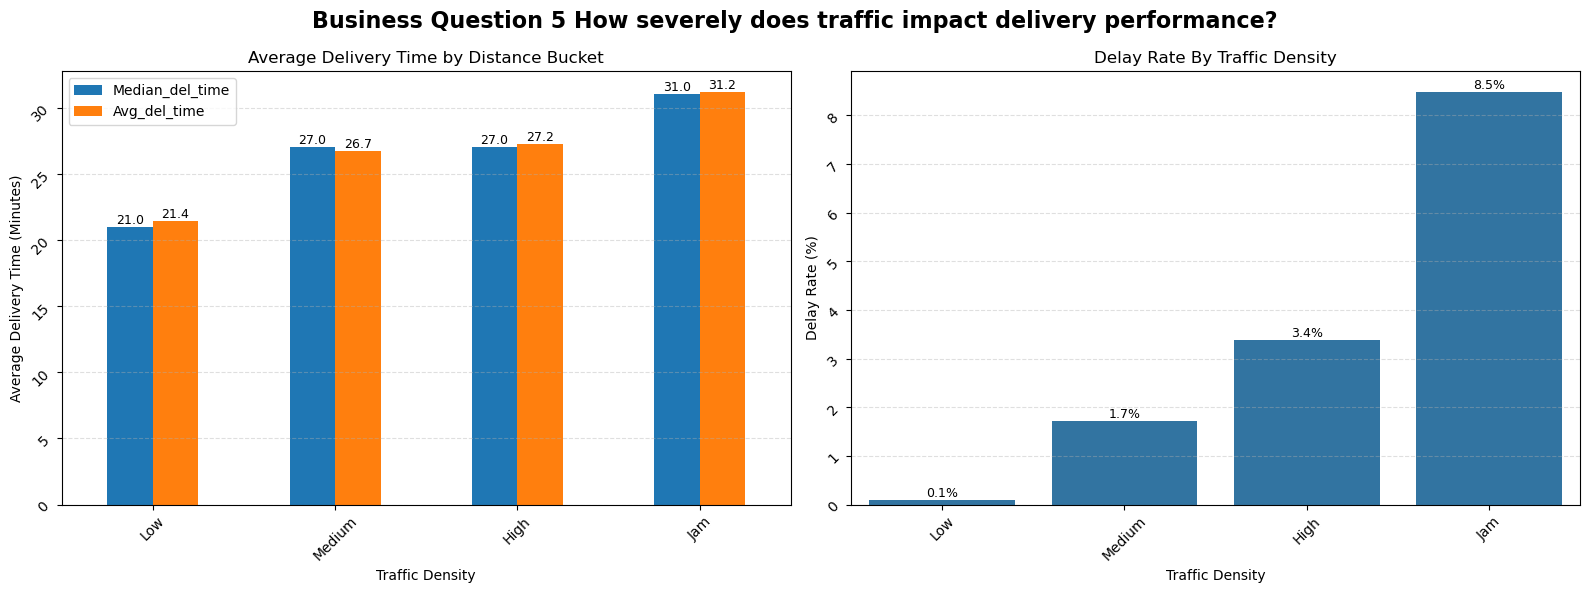

In [132]:
fig, axes = plt.subplots(1,2, figsize=(16,6))

Traffic_deliver_analysis.plot(
    x = 'road_traffic_analysis',
    y = ['Median_del_time',	'Avg_del_time'],
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Average Delivery Time by Distance Bucket')
axes[0].set_xlabel('Traffic Density')
axes[0].set_ylabel('Average Delivery Time (Minutes)')
axes[0].tick_params(rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=9)

sns.barplot(
    data=Traffic_deliver_analysis,
    x='road_traffic_analysis',
    y= 'delay_rate',
    ax=axes[1]
)
axes[1].set_title('Delay Rate By Traffic Density')
axes[1].set_xlabel('Traffic Density')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9)

    plt.suptitle(
        'Business Question 5 How severely does traffic impact delivery performance?',
        fontsize=16,
        fontweight='bold'
    )
plt.tight_layout()
plt.show()

In [133]:
low_avg_time = Traffic_deliver_analysis.loc[
    Traffic_deliver_analysis['road_traffic_analysis'] == 'Low',
    'Avg_del_time'
].values[0]

jam_avg_time = Traffic_deliver_analysis.loc[
    Traffic_deliver_analysis['road_traffic_analysis'] == 'Jam',
    'Avg_del_time'
].values[0]

traffic_impact_ratio = jam_avg_time / low_avg_time

print(f"Jam traffic deliveries take {traffic_impact_ratio:.2f}x more time than low traffic deliveries.")

Jam traffic deliveries take 1.46x more time than low traffic deliveries.


### Key Insight: Traffic Impact on Delivery Performance

Traffic has a clear impact on delivery performance. As traffic density increases from Low to Jam, average delivery time increases from **21.42 minutes** to **31.18 minutes**.

Orders in **Jam traffic** take around **1.45x longer** than orders in Low traffic. Delay rate also increases sharply from **0.10%** in Low traffic to **8.48%** in Jam traffic.

This shows that traffic congestion is one of the major reasons for delivery delays.

### Recommendation

The business should increase rider allocation in high-congestion zones and adjust delivery time estimates during Jam traffic to reduce late deliveries and improve customer experience.

# 6. Weather Analysis
## Business Question 6

How does weather affect delivery efficiency?

Analyze:

Fog
Stormy
Windy
Sunny


In [134]:
weather_delivery_affect = (
    df_clean.groupby('weather_conditions').agg(
    Total_orders = ('id', 'nunique'),
    avg_del_time = ('time_taken (min)', 'mean'),
    orderd_delay = ('is_delayed', 'sum')
)
    .reset_index()
)
weather_delivery_affect['delay_rate'] =(
    weather_delivery_affect['orderd_delay'] / weather_delivery_affect['Total_orders'] * 100
).sort_values(ascending=False) 

weather_delivery_affect = weather_delivery_affect.round(2)

print(weather_delivery_affect)

  weather_conditions  Total_orders  avg_del_time  orderd_delay  delay_rate
0             Cloudy          7482         28.92           412        5.51
1                Fog          8039         28.82           406        5.05
2         Sandstorms          7441         25.87           203        2.73
3             Stormy          7542         25.86           182        2.41
4              Sunny          7236         21.85           143        1.98
5              Windy          7382         26.13           197        2.67


In [135]:
sunny_avg_time = weather_delivery_affect.loc[
    weather_delivery_affect['weather_conditions'] == 'Sunny',
    'avg_del_time'
].values[0]

weather_delivery_affect['avg_time_increase_vs_sunny_%'] = (
    (weather_delivery_affect['avg_del_time'] - sunny_avg_time) /
    sunny_avg_time * 100
).round(2)

weather_delivery_affect

,weather_conditions,Total_orders,avg_del_time,orderd_delay,delay_rate,avg_time_increase_vs_sunny_%
0,Cloudy,7482,28.92,412,5.51,32.36
1,Fog,8039,28.82,406,5.05,31.90
2,Sandstorms,7441,25.87,203,2.73,18.40
3,Stormy,7542,25.86,182,2.41,18.35
4,Sunny,7236,21.85,143,1.98,0.00
5,Windy,7382,26.13,197,2.67,19.59


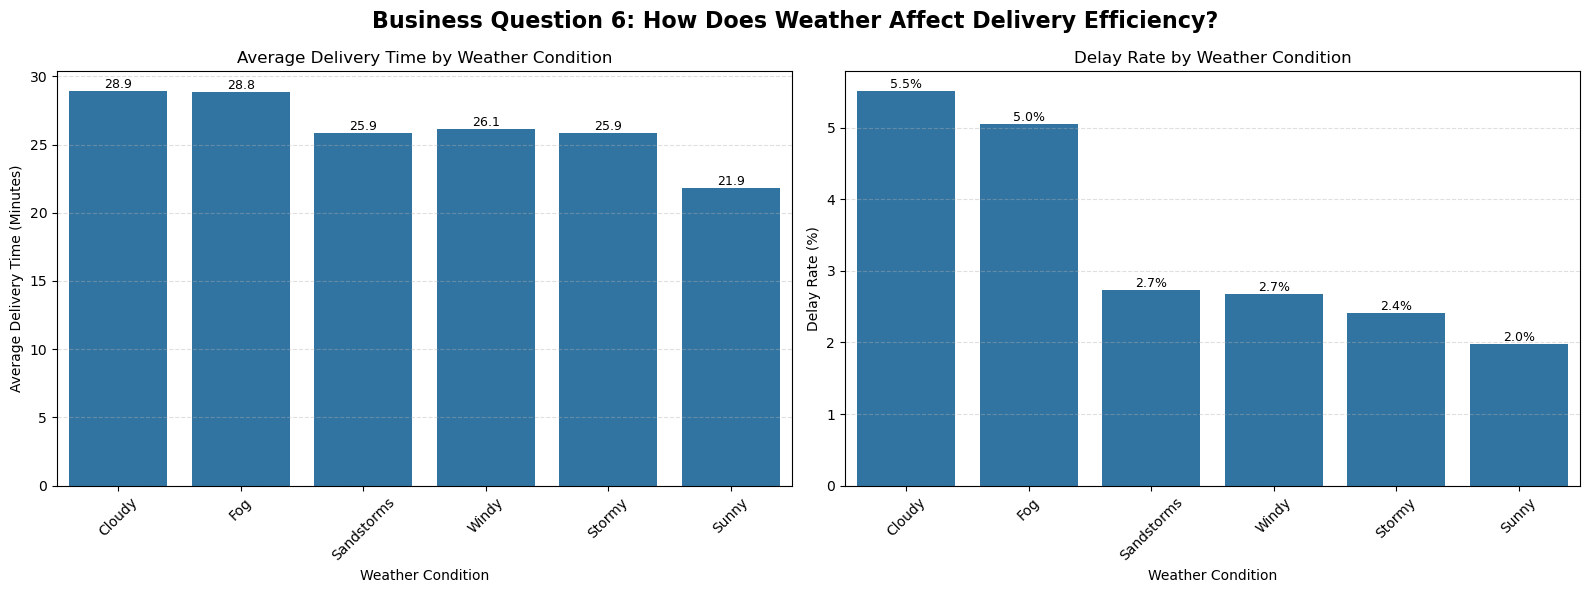

In [136]:
import matplotlib.pyplot as plt
import seaborn as sns

# index ko column mein convert karo
weather_plot = weather_delivery_affect.reset_index()

# delay_rate ke basis par sort
weather_plot = weather_plot.sort_values(by='delay_rate', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Average Delivery Time by Weather
sns.barplot(
    data=weather_plot,
    x='weather_conditions',
    y='avg_del_time',
    ax=axes[0]
)

axes[0].set_title('Average Delivery Time by Weather Condition')
axes[0].set_xlabel('Weather Condition')
axes[0].set_ylabel('Average Delivery Time (Minutes)')
axes[0].tick_params(axis='x', labelrotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=9)


# 2. Delay Rate by Weather
sns.barplot(
    data=weather_plot,
    x='weather_conditions',
    y='delay_rate',
    ax=axes[1]
)

axes[1].set_title('Delay Rate by Weather Condition')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', labelrotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9)


plt.suptitle(
    'Business Question 6: How Does Weather Affect Delivery Efficiency?',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Key Insight: Weather Impact on Delivery Efficiency

Weather conditions affect delivery efficiency. **Cloudy** and **Fog** conditions show the highest average delivery time, around **28.9 minutes**, compared to **21.85 minutes** in Sunny weather.

Cloudy weather has the highest delay rate at **5.51%**, followed by Fog at **5.05%**. This shows that poor visibility or adverse weather conditions increase delivery delay risk.

Compared to Sunny weather, Cloudy and Fog conditions increase average delivery time by around **32%**, making them the most impactful weather conditions in this dataset.

### Recommendation

The business should apply dynamic ETA adjustments during Cloudy and Fog conditions and allocate riders more carefully during poor weather to reduce late deliveries.

# 7. Multiple Deliveries Analysis ⭐⭐⭐
## Business Question 7

### Does batching multiple orders improve efficiency or create delays?

Analyze:

0
1
2
3 deliveries



In [137]:

multiple_delivery_analysis = (
    df_clean.groupby('multiple_deliveries').agg(
    Total_orders = ('id', 'nunique'),
    avg_del_time = ('time_taken (min)', 'mean'),
    Median_del_time = ('time_taken (min)', 'median'),
    orderd_delay = ('is_delayed', 'sum')
)
    .reset_index()
)
multiple_delivery_analysis['delay_rate'] =(
    multiple_delivery_analysis['orderd_delay'] / multiple_delivery_analysis['Total_orders'] * 100
)

multiple_delivery_analysis = multiple_delivery_analysis.round(2).sort_values(by='delay_rate',ascending=False) 

print(multiple_delivery_analysis)

   multiple_deliveries  Total_orders  avg_del_time  Median_del_time  \
3                  3.0           357         47.81             48.0   
2                  2.0          1972         40.44             40.0   
1                  1.0         28838         26.72             26.0   
0                  0.0         13955         22.88             22.0   

   orderd_delay  delay_rate  
3           251       70.31  
2           329       16.68  
1           744        2.58  
0           219        1.57  


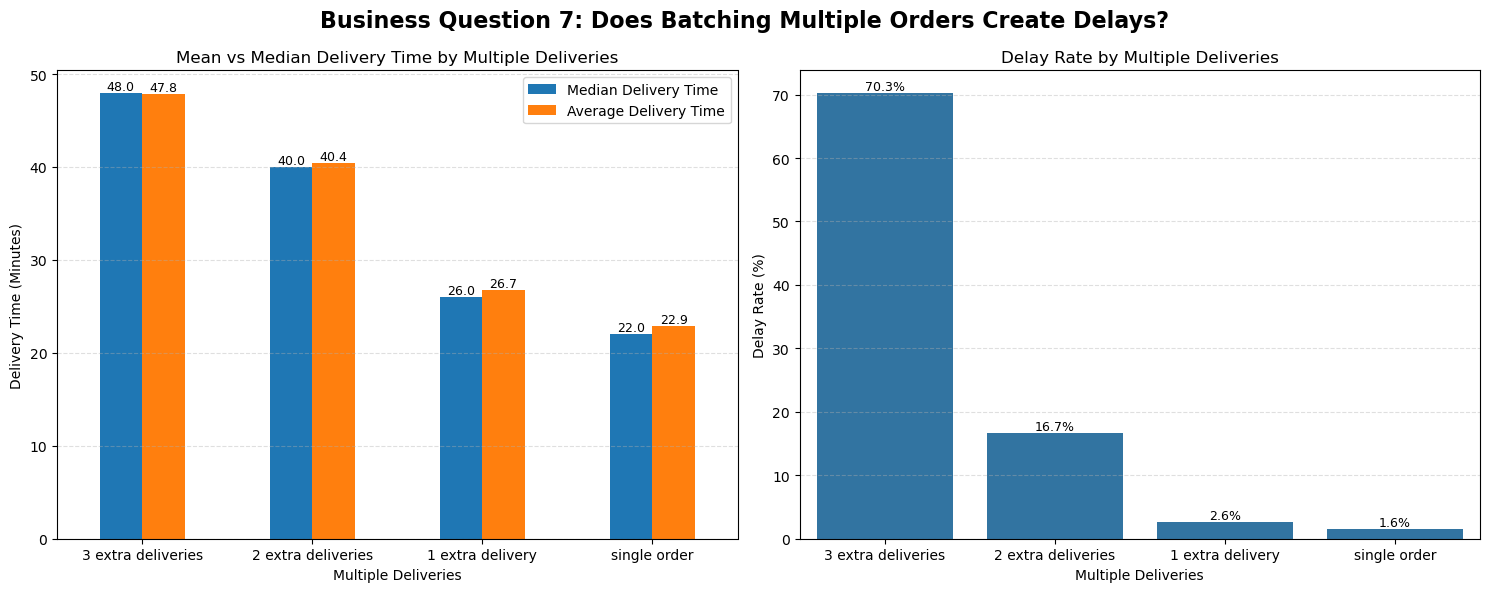

In [138]:
import matplotlib.pyplot as plt
import seaborn as sns

multiple_delivery_analysis['multiple_delivery_label'] = multiple_delivery_analysis['multiple_deliveries'].map({
    0.0: 'single order',
    1.0: '1 extra delivery',
    2.0: '2 extra deliveries',
    3.0: '3 extra deliveries'
})


fig, axes = plt.subplots(1, 2, figsize=(15, 6))

multiple_delivery_analysis.plot(
    x='multiple_delivery_label',
    y=['Median_del_time', 'avg_del_time'],
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Mean vs Median Delivery Time by Multiple Deliveries')
axes[0].set_xlabel('Multiple Deliveries')
axes[0].set_ylabel('Delivery Time (Minutes)')
axes[0].tick_params(axis='x', labelrotation=0)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend(['Median Delivery Time', 'Average Delivery Time'])

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=9)


sns.barplot(
    data=multiple_delivery_analysis,
    x='multiple_delivery_label',
    y='delay_rate',
    ax=axes[1]
)

axes[1].set_title('Delay Rate by Multiple Deliveries')
axes[1].set_xlabel('Multiple Deliveries')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', labelrotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9)

plt.suptitle(
    'Business Question 7: Does Batching Multiple Orders Create Delays?',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# 8. High Risk Deliveries 

## Business Question 8

### Can we identify deliveries that are most likely to be delayed?

Analyze:

high_risk_delivery

Compare:

High Risk
Normal


In [139]:
df_clean['high_risk_delivery'].value_counts()

high_risk_delivery
0    45122
Name: count, dtype: int64

In [140]:
df_clean = df_clean.drop(columns='high_risk_delivery', errors='coerce')

In [141]:
df_clean['high_risk_delivery'] = (
    (df_clean['road_traffic_density'] == 'Jam') &
    (df_clean['weather_conditions'].isin(['Fog', 'Stormy']))
).astype(int)

In [142]:
df_clean.head()

,id,delivery_person_id,delivery_person_age,delivery_person_ratings,restaurant_latitude,restaurant_longitude,delivery_location_latitude,delivery_location_longitude,order_date,time_orderd,time_order_picked,weather_conditions,road_traffic_density,vehicle_condition,type_of_order,type_of_vehicle,multiple_deliveries,festival,city,time_taken (min),is_delayed,order_timestamp,picked_timestamp,prep_time_minutes,order_hour,delivery_speed,time_slot,day_week,is_weekend,distance_km,distance_bucket,prep_time_bucket,road_traffic_analysis,high_risk_delivery
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,2022-02-12,21:55,22:10,Fog,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,1,2022-02-12 21:55:00,2022-02-12 22:10:00,15.0,21.0,13.397562,Night,Saturday,1,10.271464,8-12 km,10-15 min,Jam,1
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,2022-02-13,14:55,15:05,Stormy,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,0,2022-02-13 14:55:00,2022-02-13 15:05:00,10.0,14.0,16.250546,Afternoon,Sunday,1,6.229376,5-8 km,5-10 min,High,0
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,2022-03-04,17:30,17:40,Sandstorms,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,0,2022-03-04 17:30:00,2022-03-04 17:40:00,10.0,17.0,39.326588,Evening,Friday,0,13.764306,12-16 km,5-10 min,Medium,0
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,2022-02-13,09:20,09:30,Sandstorms,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,0,2022-02-13 09:20:00,2022-02-13 09:30:00,10.0,9.0,8.783384,morning,Sunday,1,2.927795,2-5 km,5-10 min,Low,0
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,2022-02-14,19:50,20:05,Fog,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,0,2022-02-14 19:50:00,2022-02-14 20:05:00,15.0,19.0,28.351440,Evening,Monday,0,19.373484,16+ km,10-15 min,Jam,1


In [143]:
high_risk_analysis = (df_clean.groupby('high_risk_delivery').agg(
    Total_orders = ('id', 'nunique'),
    Avg_del_time = ('time_taken (min)', 'mean'),
    Median_del_time = ('time_taken (min)', 'median'),
    order_delayed = ('is_delayed', 'sum')
)
    .reset_index()
    )

high_risk_analysis['high_risk_label'] = high_risk_analysis['high_risk_delivery'].map({
        0 : 'Normal risk Delivery Time',
        1 : 'High risk Delivery Time'
    })
                              

high_risk_analysis['delay_rate'] = (
    high_risk_analysis['order_delayed'] / high_risk_analysis['Total_orders'] * 100 
)

high_risk_analysis = high_risk_analysis.round(2).sort_values(by='delay_rate', ascending=False)

high_risk_analysis

,high_risk_delivery,Total_orders,Avg_del_time,Median_del_time,order_delayed,high_risk_label,delay_rate
1,1,4724,33.41,33.0,478,High risk Delivery Time,10.12
0,0,40398,25.47,25.0,1065,Normal risk Delivery Time,2.64


In [144]:
Normal_risk = high_risk_analysis.loc[
    high_risk_analysis['high_risk_delivery'] == 0,
    'Avg_del_time'
].iloc[0]

high_risk = high_risk_analysis.loc[
    high_risk_analysis['high_risk_delivery'] == 1,
    'Avg_del_time'
].iloc[0]

delivery_risk_ratio =  high_risk / Normal_risk

print(f"High risk deliveries take {delivery_risk_ratio:.2f}x more time than Normal risk deliveries.")

High risk deliveries take 1.31x more time than Normal risk deliveries.


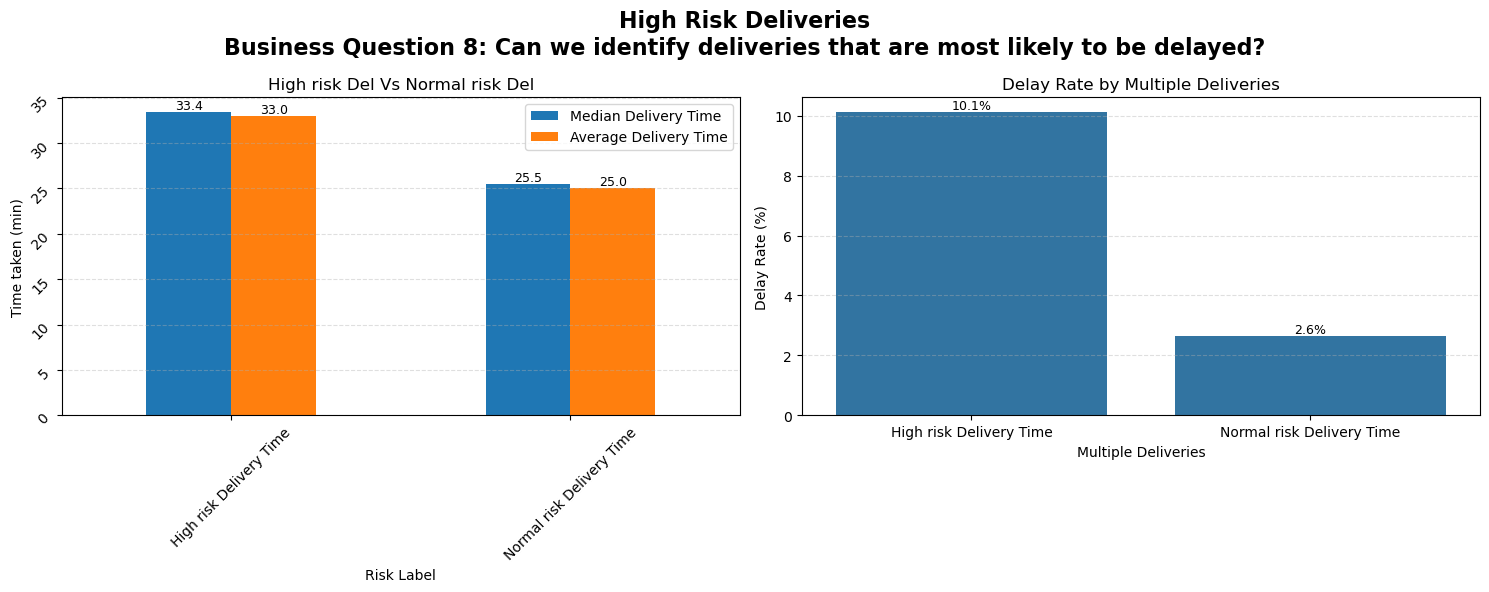

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

high_risk_analysis.plot(
    x='high_risk_label',
    y=['Avg_del_time', 'Median_del_time'],
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('High risk Del Vs Normal risk Del')
axes[0].set_xlabel('Risk Label')
axes[0].set_ylabel('Time taken (min)')
axes[0].tick_params(rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)
axes[0].legend(['Median Delivery Time', 'Average Delivery Time'])

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=9)

sns.barplot(
    data = high_risk_analysis,
    x = 'high_risk_label',
    y = 'delay_rate',
    ax=axes[1]
)

axes[1].set_title('Delay Rate by Multiple Deliveries')
axes[1].set_xlabel('Multiple Deliveries')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', labelrotation=0)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f%%', fontsize=9)

plt.suptitle(
    'High Risk Deliveries'
    '\nBusiness Question 8: Can we identify deliveries that are most likely to be delayed?',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Key Insight: High Risk Deliveries

High-risk deliveries have a much higher delay probability compared to normal deliveries. Normal deliveries have a delay rate of **2.64%**, while high-risk deliveries have a delay rate of **10.12%**.

This means high-risk deliveries are almost **3.8x more likely to be delayed** than normal deliveries.

Average delivery time also increases from **25.47 minutes** for normal deliveries to **33.41 minutes** for high-risk deliveries, showing that high-risk conditions negatively impact delivery performance.

### Recommendation

High-risk deliveries should be prioritized through better rider assignment, experienced riders, and proactive ETA adjustment to reduce late deliveries and improve customer experience.

# 9. Rider Performance Analysis ⭐⭐⭐
## Business Question 9

Do rider characteristics influence delivery performance?

Analyze:

delivery_person_ratings
delivery_person_age
delivery_speed

Insight:

Higher-rated riders consistently achieve faster delivery speeds.

In [146]:
# Add new column Distance Speed kmph for Analysis

In [147]:
df_clean['distance_speed_kmph'] = (
    df_clean['distance_km'] / df_clean['time_taken (min)']
) * 60

### Rating Bucket

In [148]:
df_clean['rating_bucket'] = pd.cut(
    df_clean['delivery_person_ratings'],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels = ['Low Rating', 'Average Rating', 'Good Rating', 'High Rating'],
    include_lowest=True
)

### Age Bucket 

In [149]:
df_clean['age_bucket'] = pd.cut(
    df_clean['delivery_person_age'],
    bins=[15, 20, 25, 30, 35, 40],
    labels=['15-20', '20-25', '25-30', '30-55', '35+'],
    include_lowest=True
)

# Rating wise rider performance

In [150]:
# rating bucket Analysis

rating_performance = (
    df_clean.groupby('rating_bucket', observed=False).agg(
        total_orders=('id', 'nunique'),
        avg_del_time = ('time_taken (min)', 'mean'),
        median_del_time = ('time_taken (min)', 'median'),
        avg_del_speed = ('distance_speed_kmph', 'mean'),
        order_delay = ('is_delayed', 'sum')
                      
        
    )
    .reset_index()
)
rating_performance['delay_rate'] = (
     rating_performance['order_delay']/ rating_performance['total_orders']  * 100
)

rating_performance  = rating_performance.round(2).sort_values(by='delay_rate', ascending=False)

rating_performance

,rating_bucket,total_orders,avg_del_time,median_del_time,avg_del_speed,order_delay,delay_rate
1,Average Rating,1923,35.89,35.0,19.45,124,6.45
2,Good Rating,8895,30.57,32.0,20.21,480,5.40
3,High Rating,33805,24.48,24.0,25.00,929,2.75
0,Low Rating,499,36.23,36.0,23.60,10,2.00


#  Age bucket Analysis

In [151]:
# Age bucket Analysis

age_performance = (
    df_clean.groupby('age_bucket', observed=False).agg(
        total_orders=('id', 'nunique'),
        avg_del_time = ('time_taken (min)', 'mean'),
        median_del_time = ('time_taken (min)', 'median'),
        avg_del_speed = ('distance_speed_kmph', 'mean'),
        order_delay = ('is_delayed', 'sum')
                      
        
    )
    .reset_index()
)
age_performance['delay_rate'] = (
     age_performance['order_delay'] / age_performance['total_orders']  * 100
)

age_performance  = age_performance.round(2).sort_values(by='delay_rate', ascending=False)

age_performance

,age_bucket,total_orders,avg_del_time,median_del_time,avg_del_speed,order_delay,delay_rate
3,30-55,10896,29.66,29.0,20.49,614,5.64
4,35+,8818,29.49,29.0,20.20,472,5.35
2,25-30,12467,24.55,23.0,25.76,310,2.49
0,15-20,2155,22.94,22.0,27.06,31,1.44
1,20-25,10786,22.98,22.0,27.19,116,1.08


In [152]:
# Delivery speed feature
df_clean['delivery_speed_kmph'] = (
    df_clean['distance_km'] / df_clean['time_taken (min)']
) * 60

# Rating bucket create
df_clean['rating_bucket'] = pd.cut(
    df_clean['delivery_person_ratings'],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=['Low Rating', 'Average Rating', 'Good Rating', 'High Rating'],
    include_lowest=True
)

# Rating performance analysis
rating_performance = (
    df_clean.groupby('rating_bucket', observed=False)
    .agg(
        total_orders=('id', 'nunique'),
        avg_del_time=('time_taken (min)', 'mean'),
        Median_del_time=('time_taken (min)', 'median'),
        avg_del_speed=('delivery_speed_kmph', 'mean'),
        delayed_orders=('is_delayed', 'sum')
    )
    .reset_index()
)

rating_performance['delay_rate'] = (
    rating_performance['delayed_orders'] /
    rating_performance['total_orders'] * 100
)

rating_performance = rating_performance.round(2)

rating_performance

,rating_bucket,total_orders,avg_del_time,Median_del_time,avg_del_speed,delayed_orders,delay_rate
0,Low Rating,499,36.23,36.0,23.60,10,2.00
1,Average Rating,1923,35.89,35.0,19.45,124,6.45
2,Good Rating,8895,30.57,32.0,20.21,480,5.40
3,High Rating,33805,24.48,24.0,25.00,929,2.75


# Rider ID wise top/bottom performance

In [153]:
rider_performance = (
    df_clean.groupby('delivery_person_id').agg(
        total_orders = ('id', 'nunique'),
        avg_del_time = ('time_taken (min)', 'mean'),
        median_del_time = ('time_taken (min)', 'median'),
        avg_del_speed = ('distance_speed_kmph', 'mean'),
        order_delay = ('is_delayed', 'sum')
    )
    .reset_index()
)

rider_performance['delay_rate'] = (
    rider_performance['order_delay'] / rider_performance['total_orders'] * 100
)

rider_performance = rider_performance.round(2).sort_values(by='delay_rate', ascending=False)
rider_performance.head(10)

,delivery_person_id,total_orders,avg_del_time,median_del_time,avg_del_speed,order_delay,delay_rate
277,BHPRES13DEL02,11,31.36,27.0,19.21,3,27.27
93,ALHRES12DEL01,12,35.00,37.5,14.01,3,25.00
759,KNPRES14DEL01,12,34.17,34.5,17.35,3,25.00
102,ALHRES15DEL01,13,30.08,28.0,18.74,3,23.08
738,KNPRES06DEL01,14,32.14,26.5,19.19,3,21.43
29,AGRRES09DEL03,10,29.00,27.0,20.29,2,20.00
838,KOCRES20DEL02,10,26.50,23.5,27.33,2,20.00
730,KNPRES03DEL02,10,26.10,22.0,21.06,2,20.00
851,KOLRES03DEL03,10,33.60,29.0,20.04,2,20.00
865,KOLRES08DEL02,10,28.60,25.0,23.84,2,20.00


In [154]:
rating_performance.columns

Index(['rating_bucket', 'total_orders', 'avg_del_time', 'Median_del_time',
       'avg_del_speed', 'delayed_orders', 'delay_rate'],
      dtype='object')

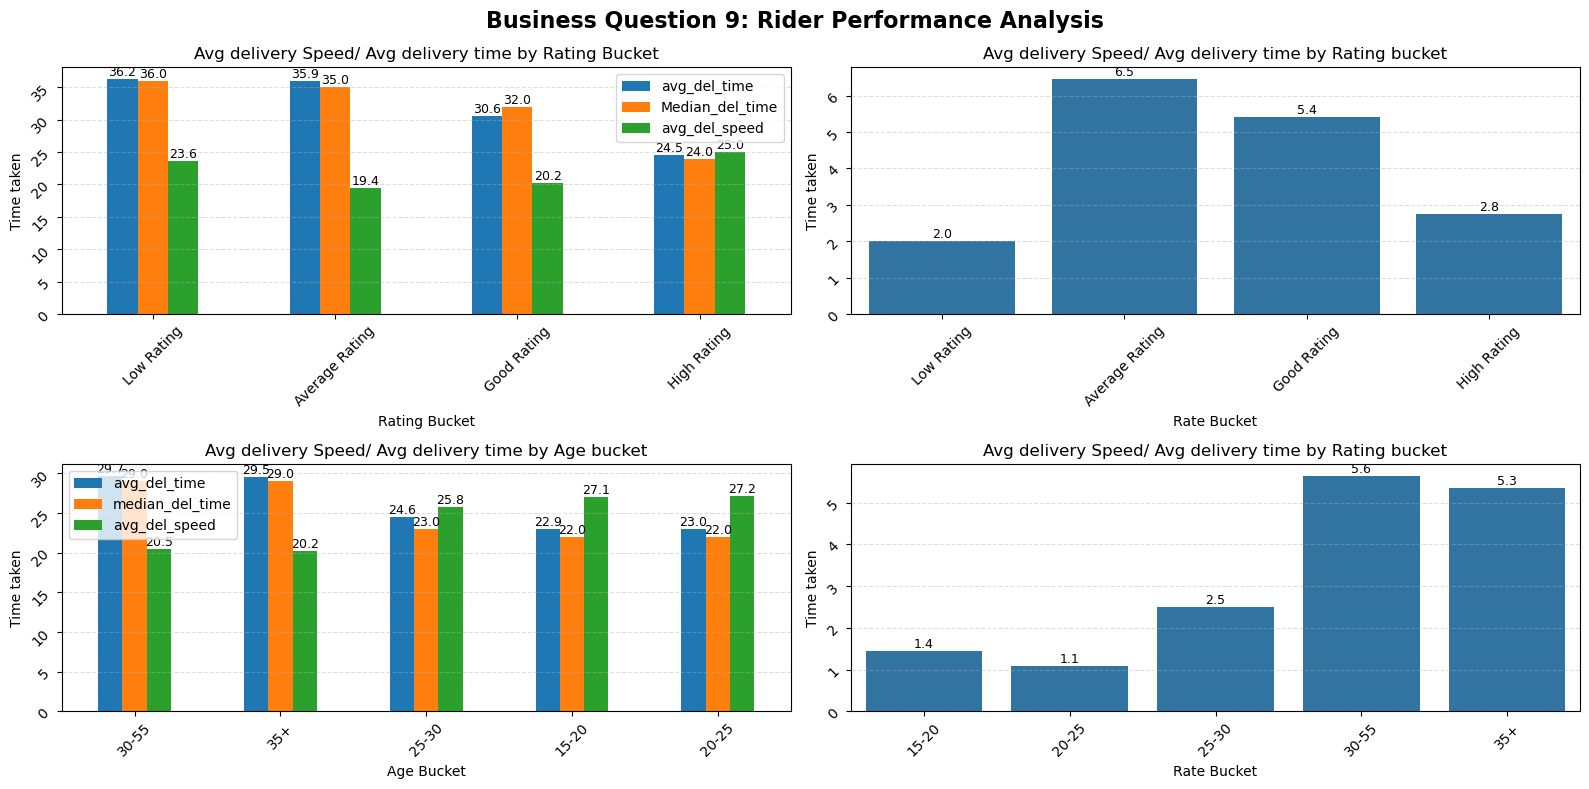

In [155]:
fig, axes= plt.subplots(2,2, figsize=(16,8))

axes = axes.flatten()

# visualize rating performance
rating_performance.plot(
    x ='rating_bucket',
    y = ['avg_del_time','Median_del_time', 'avg_del_speed'],
    kind='bar',
    ax=axes[0]
)

axes[0].set_title('Avg delivery Speed/ Avg delivery time by Rating Bucket')
axes[0].set_xlabel('Rating Bucket')
axes[0].set_ylabel('Time taken')
axes[0].tick_params(rotation=45)
axes[0].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', fontsize=9)


sns.barplot(
    data=rating_performance,
    x = 'rating_bucket',
    y = 'delay_rate',
    ax=axes[1]
)

axes[1].set_title('Avg delivery Speed/ Avg delivery time by Rating bucket')
axes[1].set_xlabel('Rate Bucket')
axes[1].set_ylabel('Time taken')
axes[1].tick_params(rotation=45)
axes[1].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.1f', fontsize=9)


# 3. Age Bucket: Delivery time and speed
age_performance.plot(
    x ='age_bucket',
    y = ['avg_del_time','median_del_time', 'avg_del_speed'],
    kind='bar',
    ax=axes[2]
)

axes[2].set_title('Avg delivery Speed/ Avg delivery time by Age bucket')
axes[2].set_xlabel('Age Bucket')
axes[2].set_ylabel('Time taken')
axes[2].tick_params(rotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.1f', fontsize=9)


# 4. Age Bucket: Delay Rate
sns.barplot(
    data=age_performance,
    x = 'age_bucket',
    y = 'delay_rate',
    ax=axes[3]
)

axes[3].set_title('Avg delivery Speed/ Avg delivery time by Rating bucket')
axes[3].set_xlabel('Rate Bucket')
axes[3].set_ylabel('Time taken')
axes[3].tick_params(rotation=45)
axes[3].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[3].containers:
    axes[3].bar_label(container, fmt='%.1f', fontsize=9)

plt.suptitle(
    'Business Question 9: Rider Performance Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

### Key Insight: Rider Performance Analysis

Rider characteristics show a clear impact on delivery performance.

Based on rider ratings, **High Rating** riders perform the best. They have the lowest average delivery time of **24.48 minutes** and the highest average delivery speed of **25.00 km/h**. This indicates that higher-rated riders generally complete deliveries faster.

However, delay rate does not decrease perfectly with rating. For example, **Average Rating** riders have the highest delay rate of **6.45%**, while **Low Rating** riders have only **2.00%** delay rate. This means rider rating alone does not fully explain delays. Other factors such as traffic, weather, distance, multiple deliveries, and order complexity also affect delivery performance.

Age-wise, younger riders perform better in this dataset. Riders in the **20-25** age group have the lowest delay rate of **1.08%** and the highest average delivery speed of **27.19 km/h**. Older rider groups show higher average delivery time and higher delay rates.

### Business Conclusion

Higher-rated and younger riders generally show better delivery efficiency, but rider performance should not be evaluated using rating or age alone. Delivery context such as traffic, weather, distance, and batching also needs to be considered.

### Recommendation

The business can assign experienced or high-performing riders to high-risk deliveries, long-distance orders, and peak-hour deliveries. Rider performance monitoring should include delivery speed, delay rate, average delivery time, and delivery conditions instead of only customer ratings.


# 10. Operational Planning Analysis ⭐⭐⭐
## Business Question 10

When should the company deploy more riders?

Analyze:

order_hour
time_slot
day_week
is_weekend

Questions:

Peak order hour?
Peak delay hour?
Weekend effect?


In [156]:
# order hour Analysis

In [157]:
def operational_summary(df, group_col):
    summary = (
        df.groupby(group_col).agg(
            total_orders=('id', 'nunique'),
            avg_del_time=('time_taken (min)', 'mean'),
            Median_del_time=('time_taken (min)', 'median'),
            avg_del_speed=('delivery_speed_kmph', 'mean'),
            delayed_orders=('is_delayed', 'sum')
        )
        .reset_index()
    )
    summary['delay_rate'] = (
    summary['delayed_orders'] / summary['total_orders'] * 100
    )
    
    return summary.round(2)


# hour Analysis

In [158]:

hour_analysis = operational_summary(df_clean, 'order_hour')

hour_analysis

,order_hour,total_orders,avg_del_time,Median_del_time,avg_del_speed,delayed_orders,delay_rate
0,8.0,1814,19.58,19.0,7.66,0,0.00
1,9.0,1934,19.56,19.0,7.67,0,0.00
2,10.0,2180,19.46,19.0,7.67,0,0.00
3,11.0,1760,27.14,27.0,5.69,48,2.73
4,12.0,889,26.83,27.0,13.47,33,3.71
5,13.0,853,27.55,27.0,14.90,35,4.10
6,14.0,715,27.56,27.0,14.82,25,3.50
7,15.0,870,23.20,23.0,17.52,1,0.11
8,16.0,771,22.92,24.0,17.82,0,0.00
9,17.0,4201,27.49,27.0,28.12,73,1.74


# Time slot Analysis

In [159]:
time_slot_analysis = operational_summary(df_clean, 'time_slot')
time_slot_analysis

,time_slot,total_orders,avg_del_time,Median_del_time,avg_del_speed,delayed_orders,delay_rate
0,Afternoon,4098,25.60,26.0,15.68,94,2.29
1,Evening,17763,29.24,29.0,26.85,913,5.14
2,Night,15573,25.61,24.0,30.66,488,3.13
3,morning,7688,21.27,20.0,7.21,48,0.62


# Day week analysis

In [160]:
day_week_analysis = operational_summary(df_clean, 'day_week')
day_week_analysis

,day_week,total_orders,avg_del_time,Median_del_time,avg_del_speed,delayed_orders,delay_rate
0,Friday,6656,26.88,26.0,25.04,255,3.83
1,Monday,5905,26.31,25.0,23.37,195,3.30
2,Saturday,5998,26.15,26.0,23.58,206,3.43
3,Sunday,5943,26.40,25.0,23.76,209,3.52
4,Thursday,6025,25.25,25.0,21.05,162,2.69
5,Tuesday,6014,25.36,25.0,20.77,171,2.84
6,Wednesday,6727,27.79,27.0,27.68,288,4.28


# is_weekend Analysis

In [161]:
weekend_analysis = operational_summary(df_clean, 'is_weekend')

weekend_analysis

,is_weekend,total_orders,avg_del_time,Median_del_time,avg_del_speed,delayed_orders,delay_rate
0,0,33181,26.31,26.0,23.85,1128,3.40
1,1,11941,26.28,26.0,23.67,415,3.48


# Peak order hour

In [162]:
peak_order_hour = (hour_analysis.sort_values(
    by='total_orders',
    ascending=False
)
 [['order_hour', 'total_orders']]
    .head()
)
peak_order_hour

,order_hour,total_orders
11,19.0,5022
14,22.0,4979
13,21.0,4670
10,18.0,4463
9,17.0,4201


# Peak delay hour

In [163]:
peak_delay_hour = (
    hour_analysis.sort_values(
    by='delay_rate',
    ascending=False
)
 [['order_hour', 'delay_rate']]
    .head()


)
peak_delay_hour

,order_hour,delay_rate
13,21.0,8.54
12,20.0,8.31
11,19.0,8.02
5,13.0,4.10
4,12.0,3.71


# weekend Analysis

In [164]:
weekend_analysis['weekend_label'] = weekend_analysis['is_weekend'].map({
    0: 'weekday',
    1: 'weekend'
})

weekend_analysis

,is_weekend,total_orders,avg_del_time,Median_del_time,avg_del_speed,delayed_orders,delay_rate,weekend_label
0,0,33181,26.31,26.0,23.85,1128,3.40,weekday
1,1,11941,26.28,26.0,23.67,415,3.48,weekend


# rider_deployemnet

In [165]:
rider_deployment_priority = (
    hour_analysis
    .sort_values(
        by=['delayed_orders', 'total_orders', 'delay_rate'],
        ascending=False
    )
    [['order_hour', 'total_orders', 'delayed_orders', 'delay_rate']]
    .head(10)
)

rider_deployment_priority

,order_hour,total_orders,delayed_orders,delay_rate
11,19.0,5022,403,8.02
13,21.0,4670,399,8.54
12,20.0,4077,339,8.31
10,18.0,4463,98,2.20
9,17.0,4201,73,1.74
3,11.0,1760,48,2.73
5,13.0,853,35,4.10
4,12.0,889,33,3.71
14,22.0,4979,32,0.64
6,14.0,715,25,3.50


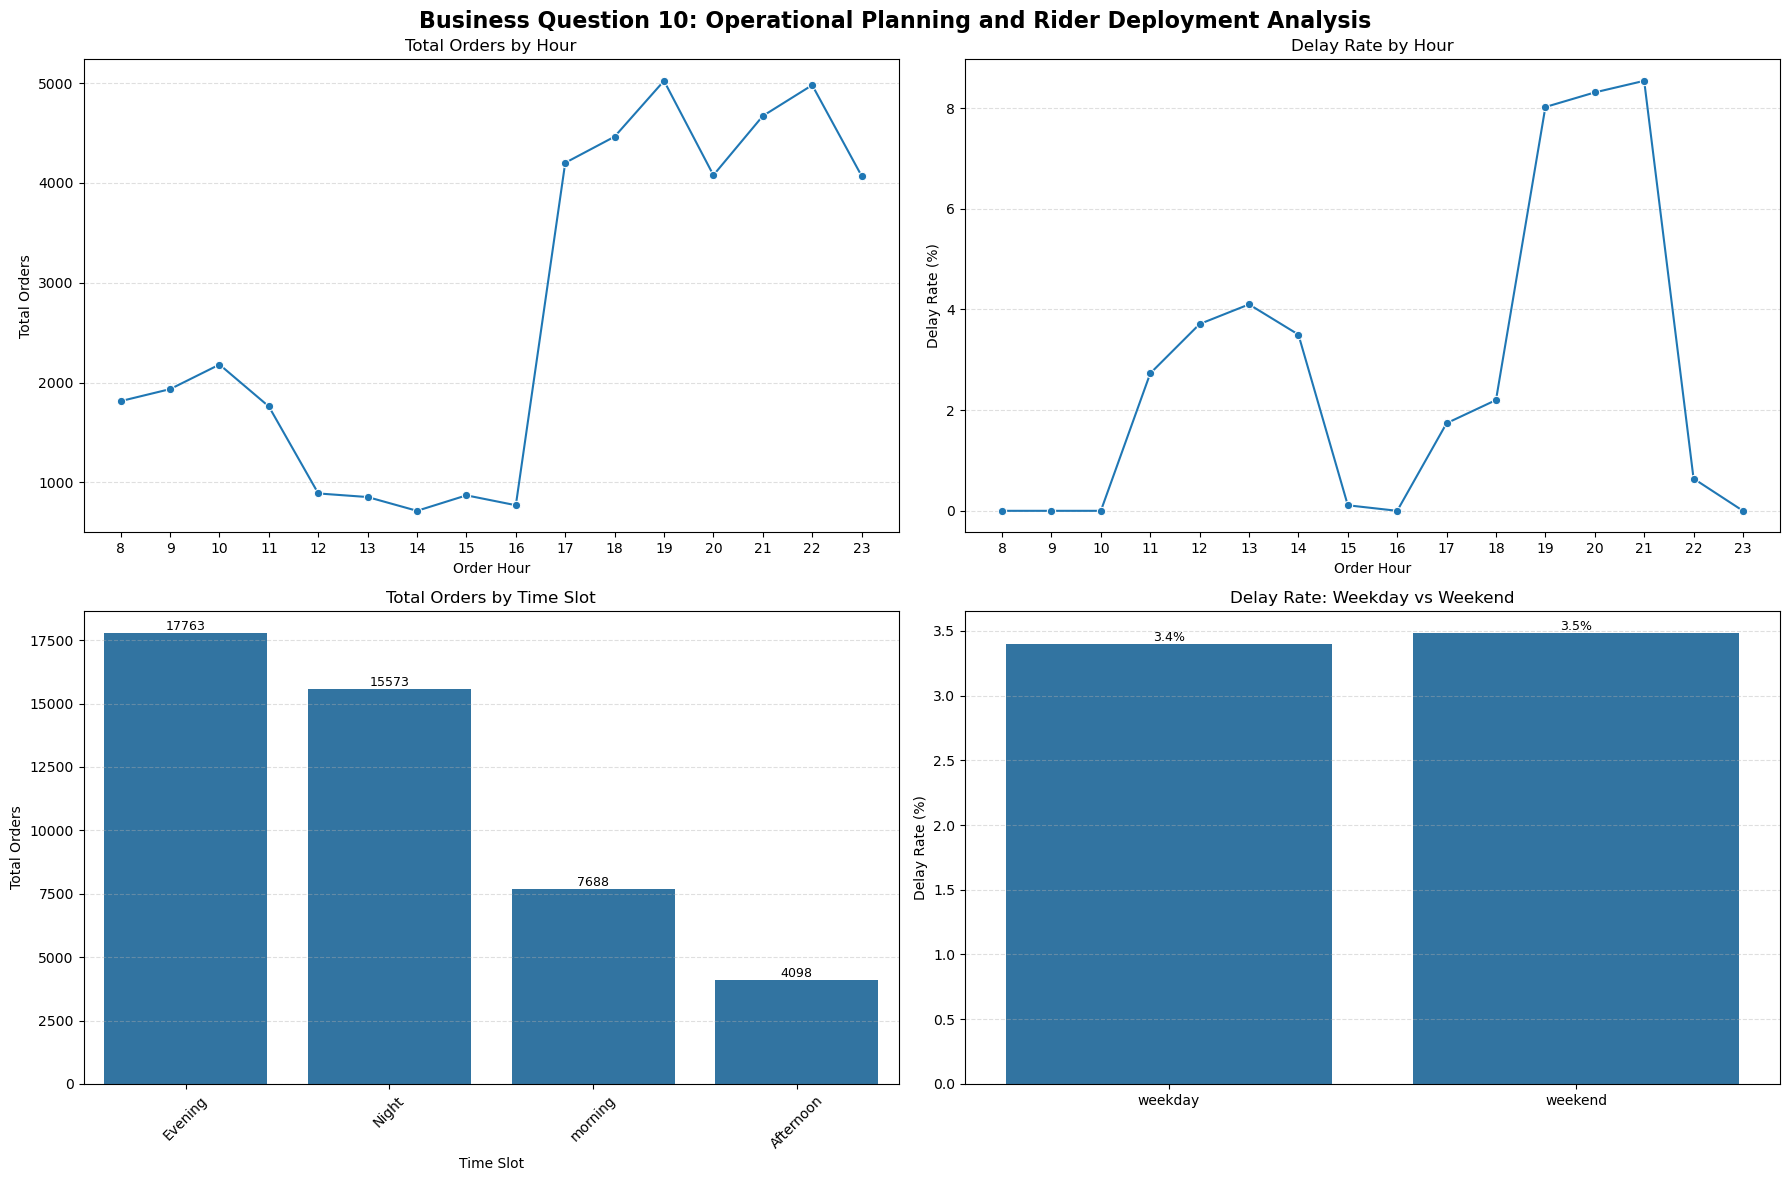

In [166]:
# Natural hour order for trend
hour_plot = hour_analysis.sort_values(by='order_hour')

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

# 1. Total Orders by Hour
sns.lineplot(
    data=hour_plot,
    x='order_hour',
    y='total_orders',
    marker='o',
    ax=axes[0]
)

axes[0].set_title('Total Orders by Hour')
axes[0].set_xlabel('Order Hour')
axes[0].set_ylabel('Total Orders')
axes[0].set_xticks(hour_plot['order_hour'])
axes[0].grid(axis='y', linestyle='--', alpha=0.4)


# 2. Delay Rate by Hour
sns.lineplot(
    data=hour_plot,
    x='order_hour',
    y='delay_rate',
    marker='o',
    ax=axes[1]
)

axes[1].set_title('Delay Rate by Hour')
axes[1].set_xlabel('Order Hour')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].set_xticks(hour_plot['order_hour'])
axes[1].grid(axis='y', linestyle='--', alpha=0.4)


# 3. Total Orders by Time Slot
time_slot_plot = time_slot_analysis.sort_values(by='total_orders', ascending=False)

sns.barplot(
    data=time_slot_plot,
    x='time_slot',
    y='total_orders',
    ax=axes[2]
)

axes[2].set_title('Total Orders by Time Slot')
axes[2].set_xlabel('Time Slot')
axes[2].set_ylabel('Total Orders')
axes[2].tick_params(axis='x', labelrotation=45)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.0f', fontsize=9)


# 4. Weekday vs Weekend Delay Rate
sns.barplot(
    data=weekend_analysis,
    x='weekend_label',
    y='delay_rate',
    ax=axes[3]
)

axes[3].set_title('Delay Rate: Weekday vs Weekend')
axes[3].set_xlabel('')
axes[3].set_ylabel('Delay Rate (%)')
axes[3].grid(axis='y', linestyle='--', alpha=0.4)

for container in axes[3].containers:
    axes[3].bar_label(container, fmt='%.1f%%', fontsize=9)


plt.suptitle(
    'Business Question 10: Operational Planning and Rider Deployment Analysis',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

# operational root cause analysis

## Step 1: High-priority rider deployment hours 

In [167]:
priority_hours = (
    hour_analysis.sort_values(
        by=['delayed_orders', 'total_orders', 'delay_rate'],
        ascending=False
    )
    .head(5)
    
)

priority_hours[['order_hour', 'total_orders', 'delayed_orders', 'delay_rate']]

priority_hours

,order_hour,total_orders,avg_del_time,Median_del_time,avg_del_speed,delayed_orders,delay_rate
11,19.0,5022,30.88,30.0,25.73,403,8.02
13,21.0,4670,31.09,31.0,25.38,399,8.54
12,20.0,4077,31.18,31.0,25.57,339,8.31
10,18.0,4463,27.27,27.0,28.07,98,2.20
9,17.0,4201,27.49,27.0,28.12,73,1.74


# Step 2: In priority hours mein traffic ka impact 

In [168]:
priority_hour_list = priority_hours['order_hour'].tolist()

priority_df = df_clean[df_clean['order_hour'].isin(priority_hour_list)]

traffic_priority_analysis = (
    priority_df.groupby(['order_hour', 'road_traffic_density'])
    .agg(
        total_orders=('id', 'nunique'),
        delayed_orders=('is_delayed', 'sum'),
        avg_del_time=('time_taken (min)', 'mean')
    )
    .reset_index()
)

traffic_priority_analysis['delay_rate'] = (
    traffic_priority_analysis['delayed_orders'] / traffic_priority_analysis['total_orders'] * 100
)

traffic_priority_analysis = traffic_priority_analysis.round(2).sort_values(by='delay_rate', ascending=False)

traffic_priority_analysis

,order_hour,road_traffic_density,total_orders,delayed_orders,avg_del_time,delay_rate
5,21.0,Jam,4670,399,31.09,8.54
2,19.0,Jam,4598,392,31.21,8.53
4,20.0,Jam,4077,339,31.18,8.31
3,19.0,Medium,424,11,27.32,2.59
1,18.0,Medium,4463,98,27.27,2.20
0,17.0,Medium,4201,73,27.49,1.74


# Traffic Heatmap visualization

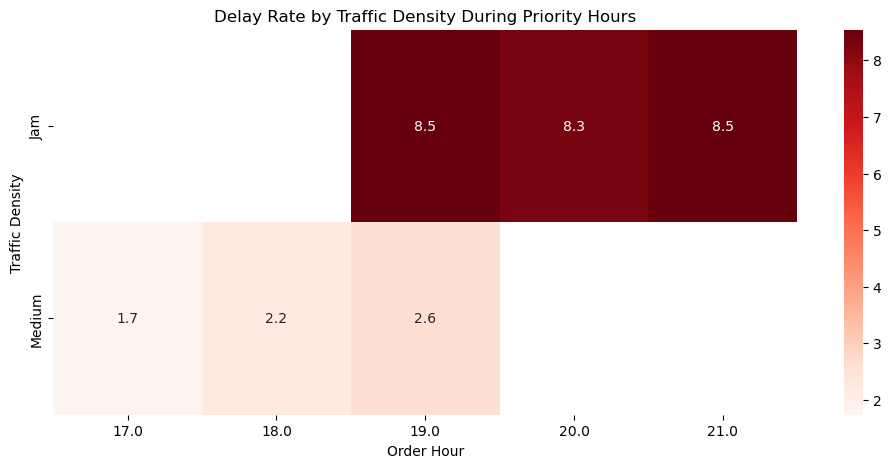

In [172]:
traffic_heatmap = traffic_priority_analysis.pivot(
    index='road_traffic_density',
    columns='order_hour',
    values='delay_rate'
    
)

plt.figure(figsize=(12,5))

sns.heatmap(
    traffic_heatmap,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Delay Rate by Traffic Density During Priority Hours')
plt.xlabel('Order Hour')
plt.ylabel('Traffic Density')
plt.show()

# weather heatmap visualization

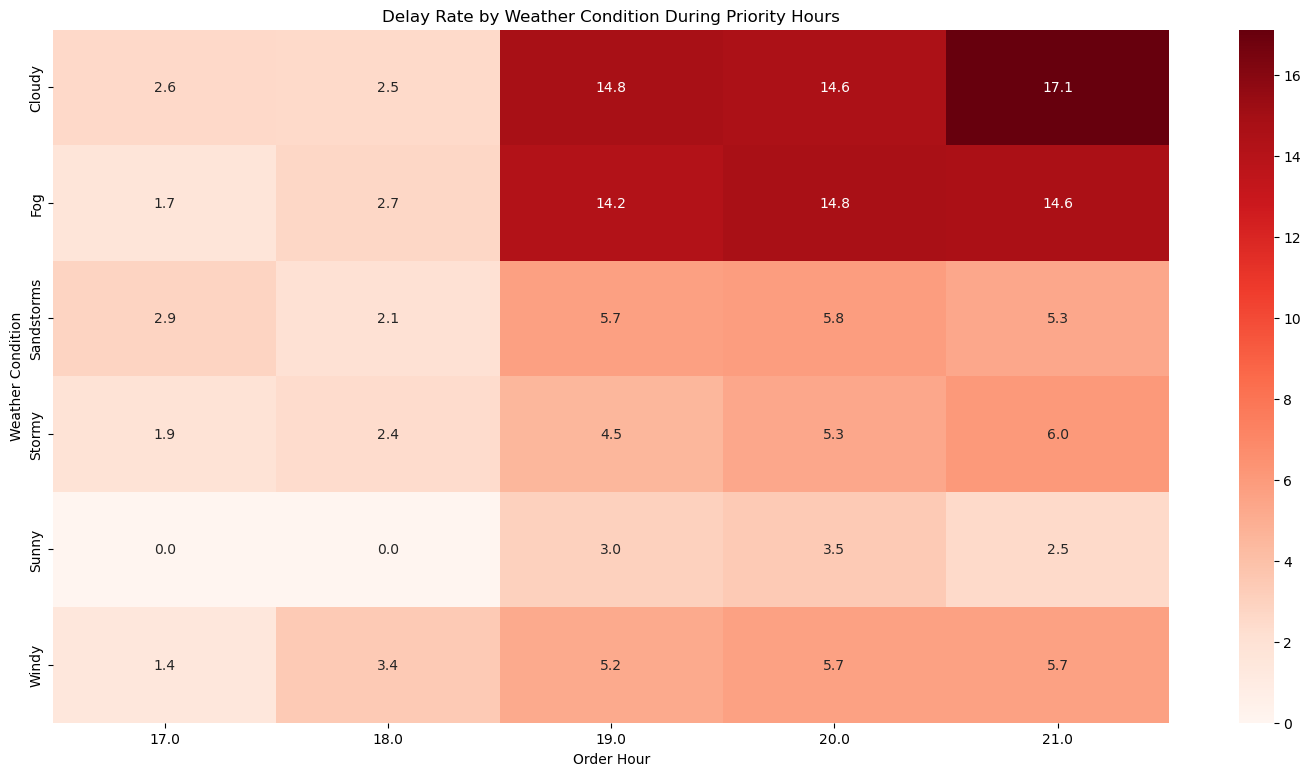

In [177]:
weather_heatmap_analysis = (
    priority_df.groupby(['order_hour', 'weather_conditions'])
    .agg(
        total_orders=('id', 'nunique'),
        delayed_order=('is_delayed', 'sum'),
        avg_time=('time_taken (min)', 'mean')
    )
    .reset_index()
)
weather_heatmap_analysis['delay_rate'] = (
    weather_heatmap_analysis['delayed_order'] / weather_heatmap_analysis['total_orders'] * 100
)
weather_heatmap_analysis =weather_heatmap_analysis.round(2)

weather_heatmap_analysis


weather_heatmap = weather_heatmap_analysis.pivot(
    index='weather_conditions',
    columns='order_hour',
    values='delay_rate'
)

plt.figure(figsize=(18,9))

sns.heatmap(
    weather_heatmap,
    annot=True,
    fmt='.1f',
    cmap='Reds'
)

plt.title('Delay Rate by Weather Condition During Priority Hours')
plt.xlabel('Order Hour')
plt.ylabel('Weather Condition')
plt.show()

### Key Insight: Operational Planning

The analysis shows that evening and night slots generate the highest order volume. Evening has the highest demand, followed by night, which indicates that rider demand is highest during these operational windows.

Hourly analysis helps identify when order volume and delay rate are high. These hours should be treated as priority rider deployment windows because they create the highest operational pressure.

Weekend and weekday delay rates are almost similar, which suggests that rider planning should focus more on hour-level and time-slot-level demand rather than only weekend vs weekday planning.

### Deep Dive

For high-priority hours, traffic and weather conditions should be analyzed separately. If delay rates are higher during jam traffic or poor weather in the same peak hours, then the delay is not only due to demand but also due to operational constraints such as congestion and adverse weather.

### Recommendation

The company should deploy additional riders during evening and night peak slots, especially in hours where both order volume and delay rate are high. During jam traffic or poor weather, ETA should be adjusted dynamically and experienced riders should be assigned to high-risk deliveries.

## Business Recommendations

1. **Limit multiple-order batching during peak periods**
   Orders with multiple deliveries show a sharp increase in delay risk. Orders with 3 multiple deliveries have the highest delay rate of **70.64%** and an average delivery time of **47.82 minutes**.
   **Recommendation:** Restrict order batching during peak demand hours and prioritize single-order assignment for high-value or high-risk customers.

2. **Increase rider allocation during jam traffic**
   Jam traffic has the highest traffic-based delay rate of **8.48%** and average delivery time of **31.18 minutes**, compared to **21.42 minutes** in low traffic.
   **Recommendation:** Deploy additional riders in high-congestion zones and use dynamic route planning during jam traffic hours.

3. **Apply dynamic ETA adjustments during poor weather**
   Cloudy and Fog conditions show the highest weather-related delay rates, with Cloudy at **5.51%** and Fog at **5.05%**. These conditions also have higher average delivery times compared to Sunny weather.
   **Recommendation:** Adjust ETA dynamically during Cloudy and Fog conditions and allocate riders more carefully during poor weather.

4. **Monitor long-distance deliveries above 8 km**
   Delay risk increases noticeably after **8 km**. The delay rate rises from **1.82%** in the 5–8 km bucket to **3.76%** in the 8–12 km bucket, and reaches around **6%** for orders above 12 km.
   **Recommendation:** Assign long-distance orders carefully during peak hours and improve ETA estimates for orders above 8 km.

5. **Prioritize high-risk deliveries**
   High-risk deliveries take **1.31x longer** than normal deliveries and are almost **3.8x more likely to be delayed**.
   **Recommendation:** Assign experienced riders to high-risk deliveries and prioritize these orders in rider allocation.

6. **Use rider performance data for smarter assignment**
   High-rated riders have better delivery performance, with lower average delivery time and higher average delivery speed. Younger rider groups also show faster delivery speed and lower delay rates in this dataset.
   **Recommendation:** Use rider rating, delivery speed, delay rate, and delivery context together when assigning riders to difficult or high-risk orders.


## Executive Summary

This project analyzed food delivery performance to identify the key factors affecting delivery delays and operational efficiency.

The analysis found that delivery delays are mainly influenced by **multiple deliveries, traffic congestion, long delivery distance, poor weather conditions, high-risk delivery situations, and rider performance**.

The strongest delay driver in this dataset is multiple deliveries. Orders with 3 multiple deliveries have a delay rate of **70.64%**, showing that excessive batching creates major delivery delays. Traffic also has a strong impact, with Jam traffic showing the highest traffic-based delay rate of **8.48%**. Distance analysis shows that delay risk increases after **8 km**, especially for orders above 12 km. Weather analysis shows that Cloudy and Fog conditions create higher delay risk compared to Sunny weather.

High-risk deliveries are also important operationally. They take **1.31x longer** than normal deliveries and are almost **3.8x more likely to be delayed**. Rider performance analysis shows that higher-rated riders generally deliver faster, but traffic, weather, distance, and batching also play a major role.

Overall, the business can reduce delays by limiting multiple-order batching during peak hours, increasing rider allocation during jam traffic, dynamically adjusting ETA during poor weather, monitoring long-distance deliveries, and prioritizing high-risk orders.


## Limitations

* Customer satisfaction ratings were not available, so the direct impact of delivery delays on customer experience could not be measured.
* Delivery distance was calculated using latitude and longitude coordinates, which may not represent actual road distance.
* Traffic and weather data were categorical, not real-time route-level data.
* Actual restaurant SLA data was limited, so restaurant preparation performance could not be fully validated.
* Some missing or unbucketed values were present in distance and preparation-time features.
* The analysis is based on historical data, so real-time operational changes such as rider availability, live traffic, and route changes were not captured.

## Future Work

* Build a machine learning model to predict delayed deliveries before rider assignment.
* Create a real-time ETA prediction system using traffic, weather, distance, rider workload, and preparation time.
* Develop a rider allocation optimization model for peak hours and high-risk deliveries.
* Build a restaurant SLA monitoring system to identify restaurants with consistently high preparation time.
* Create an interactive Power BI dashboard to monitor delivery performance, delay risk, rider efficiency, and operational bottlenecks.
